# **Trabajo Fin de Máster**

# **Optimización de la biopsia líquida mediante Machine Learning: Detección y diagnóstico del origen tumoral a partir del transcriptoma plaquetario**


## **Desarrollo de la Fase 1: comprensión de los datos**

Objetivo del bloque: cargar el conjunto de datos GSE68086 a partir de Google Drive, obtener las etiquetas correctas desde los metadatos de GEO y hacer un primer análisis exploratorio.

*Nota:* el tipo de cáncer se toma del campo "cancer type" del fichero
series_matrix de GEO, no del nombre de las columnas de la matriz de
expresión (son ambiguos: hay Type-Unknown-N, MGH-BrCa-*,...).

**Carga del conjunto de datos**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from google.colab import drive
import os

semilla = 42 # semilla fija para reproducibilidad
np.random.seed(semilla)

# Se define la paleta de colores
azul_oscuro, verde_azulado, fondo_claro = "#33415C", "#0F5C6B", "#F8F9FB"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

Para evitar bloqueos, la descarga de datos se hace de forma manual desde el enlace: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE68nnn/GSE68086 .

Los archivos se suben a Google Drive y desde allí, se conectan con Google Colab.

In [4]:
# Se conecta Google Colab con Google Drive
drive.mount('/content/drive')

ruta_drive = "/content/drive/My Drive/archivos_tfm/"

archivo_expresion = os.path.join(ruta_drive, "GSE68086_TEP_data_matrix.txt.gz")
archivo_metadatos = os.path.join(ruta_drive, "GSE68086_series_matrix.txt.gz")

# Se comprueba que la carga se ha realizado de forma correcta
if os.path.exists(archivo_expresion) and os.path.exists(archivo_metadatos):
    print("Archivos encontrados en Google Drive.\n")
else:
    print("No se han encontrado los archivos.")

Mounted at /content/drive
Archivos encontrados en Google Drive.



In [5]:
expr = pd.read_csv(archivo_expresion, sep="\t", index_col=0)
print("Dimensiones (genes × muestras):", expr.shape)   # se espera (57736, 285)
print("Ejemplo de nombres de columna:", list(expr.columns[:5]))
expr.iloc[:4, :4]

Dimensiones (genes × muestras): (57736, 285)
Ejemplo de nombres de columna: ['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl']


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100
ENSG00000000003,0,0,0,0
ENSG00000000005,0,0,0,0
ENSG00000000419,44,14,16,8
ENSG00000000457,26,1,14,0


Tal y como se esperaba, el archivo de GEO contiene 57736 genes y 285 individuos/muestras.

**Obtención de las etiquetas correctas desde los metadatos de GEO**

Se extraen desde el archivo series_matrix de GEO.
Cada muestra tiene varios campos de características (age, gender, cancer type,...).
El siguiente código imprime un ejemplo de cada campo para localizar el de "cancer type".

In [6]:
titulos = accesos = None
lista_caracteristicas = []
with gzip.open(archivo_metadatos, "rt") as f:
    for linea in f:
        if linea.startswith("!series_matrix_table_begin"):
            break
        if linea.startswith("!Sample_title"):
            titulos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_geo_accession"):
            accesos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_characteristics_ch1"):
            valores = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
            lista_caracteristicas.append(valores)

metadatos = pd.DataFrame({"titulo": titulos, "gsm": accesos})
caract_df = pd.DataFrame(lista_caracteristicas).T
caract_df.columns = [f"caracteristica_{i}" for i in range(caract_df.shape[1])]

print("Muestras en el series_matrix:", len(metadatos))
print("Campos de características por muestra:", caract_df.shape[1], "\n")
for c in caract_df.columns:
    print(c, "-->", caract_df[c].dropna().iloc[0])   # un ejemplo de cada campo

Muestras en el series_matrix: 285
Campos de características por muestra: 6 

caracteristica_0 --> tissue: blood
caracteristica_1 --> cell type: Thrombocytes
caracteristica_2 --> patient id: Breast-03
caracteristica_3 --> cancer type: Breast
caracteristica_4 --> batch: Batch03
caracteristica_5 --> mutational subclass: HER2+


Se aprecia que la característica que indica el tipo de cáncer es la 3, ya que es la que está asociada a "cancer type".

Lo siguiente es ver la distribución de los tipos de cáncer en la muestra.

In [7]:
# Se limpia el texto para quitar el prefijo "cancer type: " y quedar solo el valor
tipos_cancer = caract_df["caracteristica_3"].str.split(":", n=1).str[1].str.strip()

print("Diferentes estados (HC: Healthy control):\n")
print(tipos_cancer.unique())

print("\n\nDistribución por tipo según GEO:\n")
print(tipos_cancer.value_counts())

Diferentes estados (HC: Healthy control):

['Breast' 'Hepatobiliary' 'CRC' 'GBM' 'HC' 'Lung' 'Pancreas' 'PIK3CA' 'wt'
 'HER2+' 'KRAS' 'EGFR']


Distribución por tipo según GEO:

caracteristica_3
HC               55
GBM              40
Lung             40
CRC              38
Pancreas         35
Breast           24
Hepatobiliary    13
wt               12
KRAS             11
EGFR              9
HER2+             6
PIK3CA            2
Name: count, dtype: int64


El campo "cancer type" del archivo de series_matrix (caracteristica_3) no contiene solo los 7 grupos esperados (HC (sanos) + 6 tipos de cáncer en función del órgano afectado). Para algunas muestras de cáncer, los autores anotaron una mutación o subtipo molecular (KRAS, EGFR, HER2+, PIK3CA) o su ausencia (wt) en lugar del órgano.

El órgano de las muestras con etiqueta de mutación se determina leyendo el
título de la muestra, no suponiéndolo por la biología de la mutación (KRAS, por ejemplo, aparece en pulmón, colon y páncreas, y "wt" no indica órgano). Es decir, se detecta el órgano por palabras clave en el título y se contrasta en una tabla cruzada, de modo que la asignación quede justificada muestra a muestra.

In [8]:
import re

# Palabras clave por órgano (se buscan en el título, sin distinguir mayúsculas)
patrones_organo = {
    "Lung":          [r"lung", r"nsclc"],
    "CRC":           [r"crc", r"colo", r"rectal"],
    "GBM":           [r"gbm", r"glio"],
    "Breast":        [r"breast", r"brca", r"mamm"],
    "Pancreas":      [r"panc"],
    "Hepatobiliary": [r"hepato", r"biliary", r"chol", r"liver", r"\bhb\b"],
    "HC":            [r"healthy", r"control", r"\bhc\b"],
}

def detectar_organo(titulo):
    encontrados = [org for org, pats in patrones_organo.items()
                   if any(re.search(p, titulo, re.IGNORECASE) for p in pats)]
    if len(encontrados) == 1:
        return encontrados[0]
    if len(encontrados) == 0:
        return "SIN_DETECTAR"
    return "AMBIGUO:" + "/".join(encontrados)   # más de un órgano en el título

resolucion = pd.DataFrame({
    "titulo": metadatos["titulo"].values,
    "etiqueta_bruta": tipos_cancer.values,
})
resolucion["organo_titulo"] = resolucion["titulo"].apply(detectar_organo)

print("Etiqueta bruta  ×  órgano leído del título :\n")
print(pd.crosstab(resolucion["etiqueta_bruta"], resolucion["organo_titulo"]))

Etiqueta bruta  ×  órgano leído del título :

organo_titulo   Breast  CRC  GBM  Hepatobiliary  Lung  Pancreas  SIN_DETECTAR
etiqueta_bruta                                                               
Breast              24    0    0              0     0         0             0
CRC                  0   38    0              0     0         0             0
EGFR                 0    0    0              0     9         0             0
GBM                  0    0   40              0     0         0             0
HC                   0    0    0              0     0         0            55
HER2+                6    0    0              0     0         0             0
Hepatobiliary        0    0    0             13     0         0             0
KRAS                 0    0    0              0    11         0             0
Lung                 0    0    0              0    40         0             0
PIK3CA               2    0    0              0     0         0             0
Pancreas          

Cada muestra con etiqueta de mutación se ha asociado a un único órgano a través de su título contenido en el archivo metadatos (series_matrix), sin ningún AMBIGUO ni ningún SIN_DETECTAR entre las filas de mutación.

Por tanto, se obtiene el siguiente resultado:

- Las filas que ya traían el órgano (Breast, CRC, GBM, Hepatobiliary, Lung, Pancreas) caen enteras en su propia columna, como era de esperar.
- La fila HC aparece como SIN_DETECTAR en sus 55 muestras, y eso es correcto, ya que los títulos de los controles sanos no contienen palabras de órgano, pero tampoco las necesitan, porque para ellos usamos directamente su etiqueta HC.
- Los 9 casos de EGFR y los 11 de KRAS tienen títulos que los identifican como pulmón, así que se asignan a Lung.
- Los 6 casos de HER2+ y los 2 de PIK3CA corresponden a cáncer de mama.
- Y los 12 wt, se reparten según su título en 7 de mama, 4 de colorrectal y 1 hepatobiliar.

Al sumar cada órgano con sus muestras reasignadas, la distribución queda así:

| Clase | Directas | Reasignadas | Total |
| :--- | :---: | :--- | :---: |
| Sano (HC) | 55 | — | 55 |
| Lung | 40 | +9 EGFR +11 KRAS | 60 |
| CRC | 38 | +4 wt | 42 |
| GBM | 40 | — | 40 |
| Breast | 24 | +6 HER2+ +2 PIK3CA +7 wt | 39 |
| Pancreas | 35 | — | 35 |
| Hepatobiliary | 13 | +1 wt | 14 |


Por tanto, el dataset está compuesto de 230 individuos con cáncer, segmentados según se ve en la tabla, y 55 individuos sin cáncer.

Lo último que queda por hacer es construir una fila correspondiente a la variable objetivo en la matriz de datos procedente de data_matrix. Esto servirá para tener asociado el tipo de paciente (cáncer vs. no cáncer) a cada muestra del dataset.

Construcción de la variable objetivo (tipo_tumor):
- Muestras HC: "Sano".
- Cáncer con etiqueta de órgano: ese órgano.
- Cáncer con etiqueta de mutación: el órgano leído del título (tabla anterior).

Se tendrá que comprobar que los ficheros de series_matrix y data_matrix tienen el mismo orden aplicado a las muestras. En ese caso, será sencillo insertar la fila objetivo.

In [9]:
# Enlace por posición: la muestra n de metadatos = la columna n de expr
etiquetas_por_posicion = pd.Series(resolucion["etiqueta_bruta"].values, index=expr.columns, name="tipo_tumor")

print("Distribución de la variable objetivo (asignada por posición):")
print(etiquetas_por_posicion.value_counts(), "\n")

# Verificación independiente: órgano detectado desde el nombre de columna de expr
organo_expr = pd.Series(expr.columns, index=expr.columns).apply(detectar_organo)

print("Órgano del nombre de columna × etiqueta asignada por posición :\n")
print(pd.crosstab(organo_expr, etiquetas_por_posicion))

Distribución de la variable objetivo (asignada por posición):
tipo_tumor
HC               55
GBM              40
Lung             40
CRC              38
Pancreas         35
Breast           24
Hepatobiliary    13
wt               12
KRAS             11
EGFR              9
HER2+             6
PIK3CA            2
Name: count, dtype: int64 

Órgano del nombre de columna × etiqueta asignada por posición :

tipo_tumor     Breast  CRC  EGFR  GBM  HC  HER2+  Hepatobiliary  KRAS  Lung  \
row_0                                                                         
Breast             23    0     0    0   0      4              0     0     0   
CRC                 0   36     0    0   0      0              1     3     1   
GBM                 0    0     0   38   0      0              0     0     0   
HC                  0    0     0    0   9      0              0     0     0   
Hepatobiliary       0    0     0    0   0      0             12     0     0   
Lung                0    0     9    0   0

Como se puede observar, el orden parece no ser exactamente el mismo en los dos archivos de texto, ya que hay algunas muestras de series_matrix que corresponden a un tipo de cáncer y corresponderían a otro tipo de cáncer distinto en data_matrix. Por tanto, no se puede suponer que el orden sea el mismo.

Si se analizan los nombres de las muestras en cada uno de los archivos, se tiene que:

In [10]:
cols_expr = list(expr.columns)
titulos_meta = list(metadatos["titulo"])

print("¿Hay el mismo número de muestras?", len(cols_expr), "columnas expr /",
      len(titulos_meta), "títulos metadatos\n")

print("Columnas de expr:")
print(cols_expr[:285], "\n")
print("Títulos de metadatos:")
print(titulos_meta[:285], "\n")

# Coincidencias con distintos niveles de tolerancia
exactas = set(cols_expr) & set(titulos_meta)
print("Coincidencias exactas:", len(exactas), "de", len(cols_expr))

norm = lambda s: str(s).strip().lower().replace(" ", "")
map_norm = {norm(t): t for t in titulos_meta}
coinc_norm = sum(1 for c in cols_expr if norm(c) in map_norm)
print("Coincidencias ignorando mayúsculas/espacios:", coinc_norm, "de", len(cols_expr))

¿Hay el mismo número de muestras? 285 columnas expr / 285 títulos metadatos

Columnas de expr:
['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl', '16-Breast-WT', '21-Breast-WT', '33-Breast-Her2-ampl', '42-Breast-Her2-ampl', 'Breast-454', '48-Breast-WT', '50-Breast-WT', '55-Breast-WT', 'Type-Unknown-6', 'Breast-564', '59-Breast-WT', 'Breast-590', 'Breast-60', 'Breast-603', 'ALK61-Breast-Her2-unknown', 'Breast-85', 'Breast-86', '97-Breast-Her2-ampl', 'Breast-ALK-82', '292-Liver-KRAS', '316-Liver-KRAS', '341-Liver-WT', '376-Liver-WT', '379-Liver-WT', 'Chol-410', 'Chol-442', 'Chol-460', 'Chol-611', 'Chol-ALK-28', 'VU256-CRC', 'VU258-CRC', 'VU272-CRC', 'VU276-CRC', 'Type-Unknown-1', '329-CRC-KRAS', '342-CRC-KRAS', 'Type-Unknown-5', '354-CRC-WT', '356-CRC-WT', 'CRC-357', '374-CRC-WT', '378-CRC-WT', '420-CRC-WT', '429-CRC-WT', 'CRC-450', '453-CRC-KRAS', 'CRC-459', '462-CRC-KRAS', 'CRC-463', '466-CRC-KRAS', '474-CRC-WT', 'CRC-487', 'CRC-496', '497

Ambos archivos de texto tienen nombres diferentes asociados a cada una de las muestras.

La matriz de expresión usa nombres como '3-Breast-Her2-ampl' o 'VU274-CRC', mientras que el series_matrix (matriz de metadatos) emplea el formato 'Blood_Platelets_Breast-03'.

No hay ninguna coincidencia exacta entre ambos conjuntos de nombres, ni tampoco al ignorar mayúsculas y espacios, por lo que no es posible enlazarlos directamente por texto. El emparejamiento por posición tampoco funciona, ya que el orden de las muestras difiere entre los dos archivos, sobre todo en el tramo final (las muestras con prefijo 'MGH-' y 'Vumc-').

Además, el nombre de columna de la matriz de expresión no siempre indica el
órgano correcto. Por ejemplo, la columna 'VU274-CRC' aparece en el
series_matrix como 'Liver-274', es decir, hepatobiliar, y 'MGH-CRC-BRAF4' como 'Chol-BRAF4', también hepatobiliar. Tomar la clase del nombre de
columna daría 44 muestras de colorrectal y 12 de hepatobiliar, en lugar de las 42 y 14 que registra el series_matrix. Por este motivo, la clase de cada
muestra se toma siempre del metadato de GEO, que es la fuente autorizada, y no del nombre de la columna.

El enlace entre ambos archivos se construye entonces, a partir del código identificador de la muestra (el número o código corto que ambos archivos comparten), depurado para que sea comparable entre los dos formatos.

La clase la aporta el metadato, y el órgano leído del nombre de columna se usa únicamente como pista para desempatar los pocos códigos que se repiten en más de un órgano. Las muestras de control sano ('HD-' y 'Control-') se identifican directamente por su prefijo. Por último, las cinco muestras señaladas como 'Type-Unknown-N' en el data_matrix, que carecen de
código aprovechable, se resuelven a partir de la clase de sus muestras
contiguas en la matriz, y solo cuando estas coinciden.

Todo el proceso se valida al final contrastando la distribución de clases obtenida con la que registra el series_matrix, de modo que la asignación quede comprobada y no dependa de ningún supuesto.

In [11]:
from collections import defaultdict

def limpiar_codigo(texto):
    if not isinstance(texto, str):
        return ""
    t = re.sub(r"[^A-Za-z0-9]", "", texto.upper())      # solo alfanumérico
    m = re.match(r"^([A-Z]*)0*(\d+)([A-Z]*)$", t)         # quita ceros a la izquierda
    return m.group(1) + m.group(2) + m.group(3) if m else t

# El órgano del metadato es la verdad de referencia (Chol y Liver = hepatobiliar)
mapa_clase = {"Breast": "Breast", "CRC": "CRC", "GBM": "GBM",
              "Chol": "Hepatobiliary", "Liver": "Hepatobiliary",
              "Lung": "Lung", "Panc": "Pancreas", "HC": "Sano"}

nucleo    = metadatos["titulo"].str.replace("Blood_Platelets_", "", regex=False)
org_meta  = nucleo.str.split("-", n=1).str[0]
cod_meta  = nucleo.str.split("-", n=1).str[1].str.replace("ALK", "", regex=False).apply(limpiar_codigo)
metadatos["clase"]  = org_meta.map(mapa_clase)
metadatos["codigo"] = cod_meta

print("Distribución según metadatos (referencia):")
print(metadatos["clase"].value_counts(), "\n")

# Índice codigo: clases posibles (para desempatar colisiones de código)
codigo_a_clases = defaultdict(set)
for cod, cls in zip(metadatos["codigo"], metadatos["clase"]):
    codigo_a_clases[cod].add(cls)

Distribución según metadatos (referencia):
clase
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64 



In [12]:
# Pista de órgano a partir del nombre de columna (solo para desempatar)
pistas = {"BrCa": "Breast", "Breast": "Breast", "NSCLC": "Lung", "Lung": "Lung",
          "CRC": "CRC", "GBM": "GBM", "Pancr": "Pancreas", "Panc": "Pancreas",
          "Liver": "Hepatobiliary", "Chol": "Hepatobiliary",
          "HD": "Sano", "Control": "Sano"}

def pista_organo(nombre):
    for token, cls in pistas.items():
        if re.search(token, nombre, re.IGNORECASE):
            return cls
    return None

def codigo_expr(nombre):
    s = nombre.upper()
    s = re.sub(r"PLATELET-?HISEQ|-?TR-?\d+|HER2|AMPL|UNKNOWN|-WT|-KRAS|-EGFR|VIII", " ", s)
    for t in ["BLOOD_PLATELETS", "MGH", "VUMC", "VU", "BREAST", "BRCA", "NSCLC",
              "LUNG", "CRC", "GBM", "PANCR", "PANC", "LIVER", "CHOL",
              "HD", "CONTROL", "ALK"]:
        s = re.sub(t, " ", s)
    s = re.sub(r"(\d)J", r"\1", s)      # quita la J de sufijos tipo 0020J
    return limpiar_codigo(s)

filas = []
for col in expr.columns:
    pista = pista_organo(col)
    if pista == "Sano":                     # todo HD/Control es sano, sin cruzar número
        clase, origen = "Sano", "sano"
    else:
        cod = codigo_expr(col)
        posibles = codigo_a_clases.get(cod, set())
        if len(posibles) == 1:              # código único: manda el metadato
            clase, origen = next(iter(posibles)), "codigo"
        elif len(posibles) > 1:             # choque de códigos: desempata la pista
            clase = pista if pista in posibles else None
            origen = "codigo+pista"
        else:                               # sin match de código: usa la pista
            clase, origen = pista, ("pista" if pista else "SIN_RESOLVER")
    filas.append((col, pista, clase, origen))

diag = pd.DataFrame(filas, columns=["columna", "pista", "clase", "origen"])

print("Resueltas por origen:")
print(diag["origen"].value_counts(), "\n")
print("Columnas SIN RESOLVER:")
print(diag[diag["clase"].isna()]["columna"].tolist(), "\n")
print("Distribución provisional en expr:")
print(diag["clase"].value_counts())

Resueltas por origen:
origen
codigo          169
sano             54
codigo+pista     43
pista            14
SIN_RESOLVER      5
Name: count, dtype: int64 

Columnas SIN RESOLVER:
['Type-Unknown-6', 'Type-Unknown-1', 'Type-Unknown-5', 'Type-Unknown-3', 'Type-Unknown-4'] 

Distribución provisional en expr:
clase
Lung             60
Sano             54
CRC              40
GBM              40
Breast           38
Pancreas         34
Hepatobiliary    14
Name: count, dtype: int64


In [13]:
# Las Type-Unknown se resuelven por la clase de sus columnas vecinas en la matriz.
# Solo se asigna si las dos vecinas coinciden (no se rellena a ojo).
orden = list(expr.columns)
clase_por_col = dict(zip(diag["columna"], diag["clase"]))

for col in diag.loc[diag["clase"].isna(), "columna"]:
    i = orden.index(col)
    vecinas = [clase_por_col.get(orden[j]) for j in (i - 1, i + 1)
               if 0 <= j < len(orden)]
    vecinas = [v for v in vecinas if v]
    if len(set(vecinas)) == 1:
        clase_por_col[col] = vecinas[0]
        print(f"{col}: -> {vecinas[0]}  (vecinas: {orden[i-1]}, {orden[i+1]})")
    else:
        print(f"{col}: vecinas discrepantes {vecinas}, requiere revisión manual")

# Etiquetas finales
etiquetas = pd.Series([clase_por_col[c] for c in expr.columns], index=expr.columns, name="tipo_tumor")

esperado = {"Lung": 60, "Sano": 55, "CRC": 42, "GBM": 40, "Breast": 39, "Pancreas": 35, "Hepatobiliary": 14}
print("\nSin etiqueta:", etiquetas.isna().sum())
print(etiquetas.value_counts())
print("\n¿Coincide con la referencia del metadato?",
      etiquetas.value_counts().to_dict() == esperado)

Type-Unknown-6: -> Breast  (vecinas: 55-Breast-WT, Breast-564)
Type-Unknown-1: -> CRC  (vecinas: VU276-CRC, 329-CRC-KRAS)
Type-Unknown-5: -> CRC  (vecinas: 342-CRC-KRAS, 354-CRC-WT)
Type-Unknown-3: -> Sano  (vecinas: Control-13, HD-17-1)
Type-Unknown-4: -> Pancreas  (vecinas: 448-Pancr-KRAS, Panc-451)

Sin etiqueta: 0
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64

¿Coincide con la referencia del metadato? True


Una vez encontrada la correspondencia, es momento de insertar la fila objetivo en la matriz de datos.

In [14]:
# Para no modificar la matriz original, se trabajará con una copia
expr_con_obj = expr.copy()

# Se añade la variable objetivo como nueva fila
expr_con_obj.loc["tipo_tumor"] = etiquetas

print("Dimensiones de la matriz original (intacta):", expr.shape)
print("Dimensiones de la matriz copia (con la etiqueta):", expr_con_obj.shape)

# Vemos las últimas filas de la copia para confirmarlo
expr_con_obj.tail(3)

Dimensiones de la matriz original (intacta): (57736, 285)
Dimensiones de la matriz copia (con la etiqueta): (57737, 285)


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,48-Breast-WT,50-Breast-WT,55-Breast-WT,Type-Unknown-6,Breast-564,...,MGH-NSCLC-L07-TR459,MGH-NSCLC-L11-TR477,MGH-NSCLC-L12-TR478,MGH-NSCLC-L18-TR479,MGH-NSCLC-L19-TR461,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
ENSG00000273492,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273493,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
tipo_tumor,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,...,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung


Con la fila de etiquetas ya insertada en la matriz de datos, se puede realizar el análisis exploratorio inicial.

**Análisis exploratorio inicial**

En este apartado se comprueba la existencia de valores faltantes, se examina la distribución de los valores de expresión y la escala de los conteos, se cuantifica el desbalance entre clases y se identifican las réplicas presentes en el conjunto.

In [15]:
# Primero se estudia la existencia de valores faltantes
n_faltantes = int(expr.isna().sum().sum())
prop_ceros = (expr == 0).to_numpy().mean()

print("Valores faltantes (NaN) en la matriz:", n_faltantes)
print(f"Proporción de ceros en la matriz: {prop_ceros:.2%}")
print("Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.")

Valores faltantes (NaN) en la matriz: 0
Proporción de ceros en la matriz: 85.21%
Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.


Este dataset no presenta valores faltantes, por lo que el siguiente paso es ver cómo se comportan los valores de expresión.

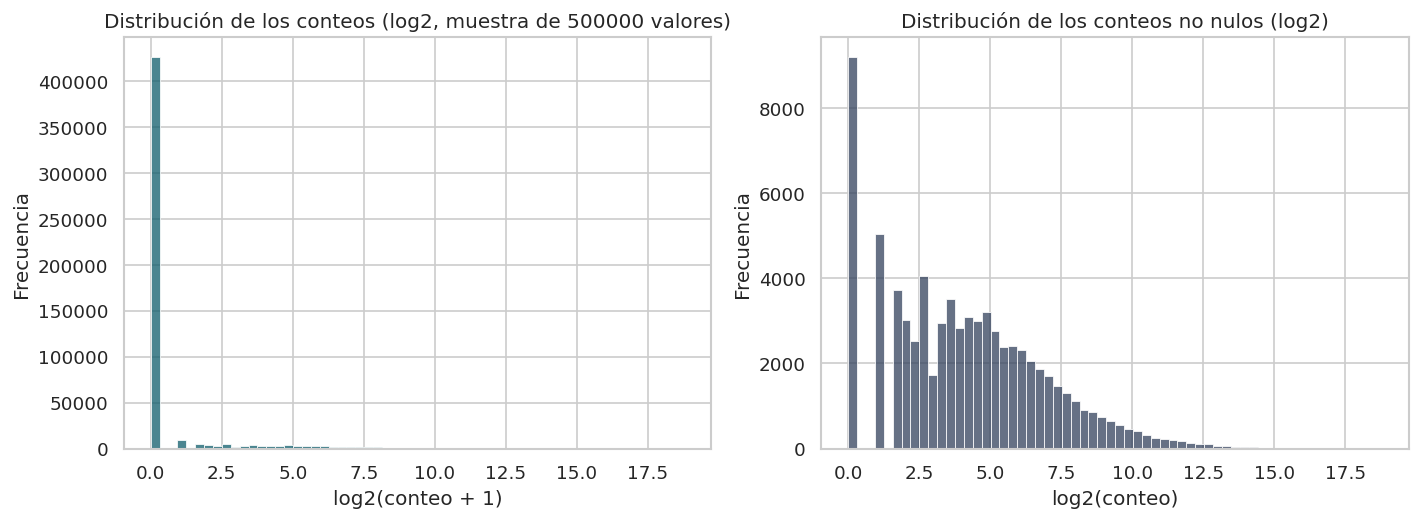

In [16]:
# Lo siguiente es ver cómo se distribuyen los valores de expresión
rng = np.random.default_rng(semilla)

# La matriz tiene millones de valores, por lo que, se toma una muestra para el histograma
valores = expr.to_numpy().ravel()
muestra_val = rng.choice(valores, size=500_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(np.log2(muestra_val + 1), bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Distribución de los conteos (log2, muestra de 500000 valores)")
ejes[0].set_xlabel("log2(conteo + 1)"); ejes[0].set_ylabel("Frecuencia")

no_nulos = muestra_val[muestra_val > 0]
sns.histplot(np.log2(no_nulos), bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Distribución de los conteos no nulos (log2)")
ejes[1].set_xlabel("log2(conteo)"); ejes[1].set_ylabel("Frecuencia")

plt.tight_layout(); plt.show()

Las dos gráficas muestran la distribución de los valores de expresión en escala logarítmica en base 2. En la primera se representan todos los valores de la matriz, sumando una unidad antes de transformar para poder incluir los ceros. La barra situada en el extremo izquierdo corresponde justamente a esos ceros, que suponen el 85.21% de la matriz y dominan por completo la distribución. El resto de valores se reparte en una curva que desciende de forma continua a medida que aumenta la expresión.

La segunda gráfica excluye los ceros para poder observar los valores realmente detectados. La distribución sigue siendo claramente asimétrica hacia la derecha: la mayor parte de los genes presenta conteos bajos y solo una minoría alcanza valores muy altos, que se extienden en una cola larga. El hecho de que esta asimetría se mantenga tras eliminar los ceros indica que no la provocan las ausencias de expresión, sino la propia naturaleza de los datos de secuenciación, en los que unos pocos genes muy activos concentran una gran parte de las lecturas.

Ambas gráficas condicionan el preprocesado dado que la abundancia de ceros justifica el filtrado de los genes que apenas se detectan, ya que no aportan información y solo añaden dimensionalidad. La asimetría, por su parte, justifica la transformación logarítmica, que comprime el rango de valores y evita que los genes más expresados dominen el entrenamiento de los modelos.

Comprobada la distribución de los valores de expresión, es necesario examinar la escala de los conteos desde dos puntos de vista.

Por muestra, interesa saber cuántas lecturas totales se han obtenido en cada una, ya que ese volumen condiciona directamente la magnitud de sus valores. Por gen, interesa conocer en cuántas muestras se detecta expresión, lo que permite estimar qué proporción del transcriptoma aporta información real al análisis.

Lecturas por muestra -> mín 218,517 | mediana 2,015,926 | máx 7,273,295
Genes sin ninguna lectura en todas las muestras: 29,195
Genes con cero en más del 90% de las muestras: 44,291


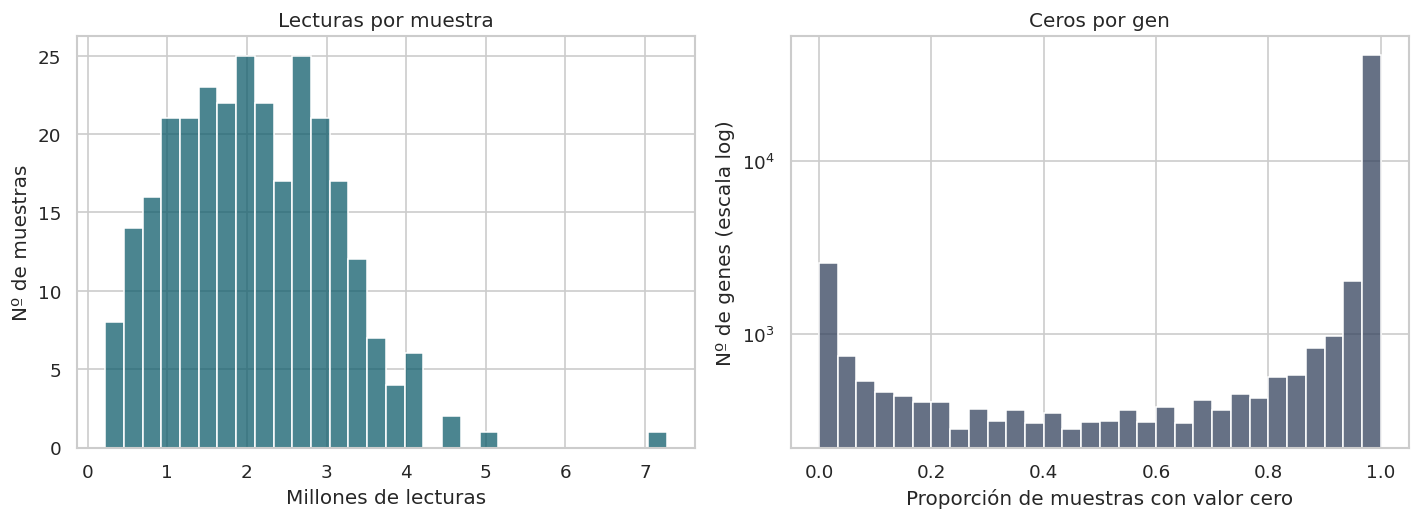

In [17]:
# El siguiente paso es la escala de los conteos de las muestras
tam_libreria = expr.sum(axis=0)             # lecturas por muestra
ceros_por_gen = (expr == 0).mean(axis=1)    # fracción de muestras con cero, por gen
genes_todo_cero = int((expr.sum(axis=1) == 0).sum())

print(f"Lecturas por muestra -> mín {tam_libreria.min():,.0f} | "
      f"mediana {tam_libreria.median():,.0f} | máx {tam_libreria.max():,.0f}")
print(f"Genes sin ninguna lectura en todas las muestras: {genes_todo_cero:,}")
print(f"Genes con cero en más del 90% de las muestras: {(ceros_por_gen > 0.9).sum():,}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(tam_libreria / 1e6, bins=30, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Lecturas por muestra")
ejes[0].set_xlabel("Millones de lecturas"); ejes[0].set_ylabel("Nº de muestras")

sns.histplot(ceros_por_gen, bins=30, color=azul_oscuro, ax=ejes[1])
ejes[1].set_yscale("log")                   # comprime el pico y deja ver los grupos pequeños
ejes[1].set_title("Ceros por gen")
ejes[1].set_xlabel("Proporción de muestras con valor cero")
ejes[1].set_ylabel("Nº de genes (escala log)")

plt.tight_layout(); plt.show()

In [18]:
tramos = {
    "Presentes en todas las muestras (0 % de ceros)": (ceros_por_gen == 0).sum(),
    "Ceros en menos del 10 % de las muestras":        (ceros_por_gen < 0.1).sum(),
    "Zona intermedia (entre 10 % y 90 %)":            ((ceros_por_gen >= 0.1) & (ceros_por_gen <= 0.9)).sum(),
    "Ceros en más del 90 %":                          (ceros_por_gen > 0.9).sum(),
    "Ceros en el 100 % de las muestras":              (ceros_por_gen == 1).sum(),
}
for k, v in tramos.items():
    print(f"{k}: {v:,}")

Presentes en todas las muestras (0 % de ceros): 959
Ceros en menos del 10 % de las muestras: 3,851
Zona intermedia (entre 10 % y 90 %): 9,594
Ceros en más del 90 %: 44,291
Ceros en el 100 % de las muestras: 29,195


El tamaño de librería varía de forma considerable entre muestras. La mediana se sitúa en algo más de dos millones de lecturas, pero el rango va desde las 218.517 hasta los 7.273.295, más de treinta veces de diferencia. Sin embargo, los conteos en bruto no son comparables entre muestras, ya que un valor elevado puede reflejar tanto una expresión alta como una secuenciación más profunda. Corregir este efecto es el motivo por el que los datos se transforman a conteos por millón antes del modelado.

La segunda gráfica sitúa cada gen según la proporción de muestras en las que su valor es cero. Un gen que nunca se detecta se sitúa en el extremo derecho, en 1,0, mientras que uno presente en todas las muestras aparece en el extremo izquierdo, en 0,0. La altura de cada barra indica cuántos genes caen en ese tramo, y el eje vertical se representa en escala logarítmica porque, de otro modo, la barra del extremo derecho ocultaría por completo al resto.

El grupo más numeroso se acumula en el extremo derecho. Un total de 29.195 genes carecen de lecturas en las 285 muestras, algo más de la mitad de la matriz, y al ampliar el tramo a los que están a cero en más del 90 % de las muestras la cifra alcanza los 44.291 genes, es decir, más o menos tres cuartas partes del total. En el extremo opuesto se sitúan 3.851 genes que se detectan en más del 90 % de las muestras, de los cuales 959 están presentes en todas ellas sin excepción. Entre ambos extremos queda una zona intermedia de 9.594 genes, cuya presencia varía de unas muestras a otras.

Este reparto condiciona la dimensionalidad del problema, dado que la mayor parte de las 57.736 variables no contiene información aprovechable para distinguir entre clases y solo agrava el desajuste entre el número de variables y el de muestras.

La escala logarítmica del gráfico conviene interpretarla con cuidado, ya que reduce visualmente la importancia de los grupos menos numerosos: la zona intermedia parece inexistente, pero reúne casi diez mil genes. Su existencia implica que el corte entre lo que se expresa y lo que no resulta gradual, sin una frontera evidente, de modo que el umbral de filtrado que abre la siguiente fase constituye una decisión metodológica que debe justificarse de forma explícita y no un valor que los datos determinen por sí solos.

Una vez estudiados los valores de expresión, queda por mirar la variable objetivo.

El reparto de las muestras entre clases determina si los modelos tenderán a favorecer a las categorías más frecuentes y condiciona tanto las métricas de evaluación como las estrategias correctoras que deben aplicarse. Se analiza en sus dos formulaciones: la binaria, que separa a las personas sin cáncer de las que lo padecen, y la multiclase, que distingue el tipo de tumor.

Distribución multiclase:
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64 

Distribución binaria:
tipo_tumor
Cáncer    230
Sano       55
Name: count, dtype: int64 

Razón de desbalance multiclase: 4.3 a 1
Razón de desbalance binaria:    4.2 a 1


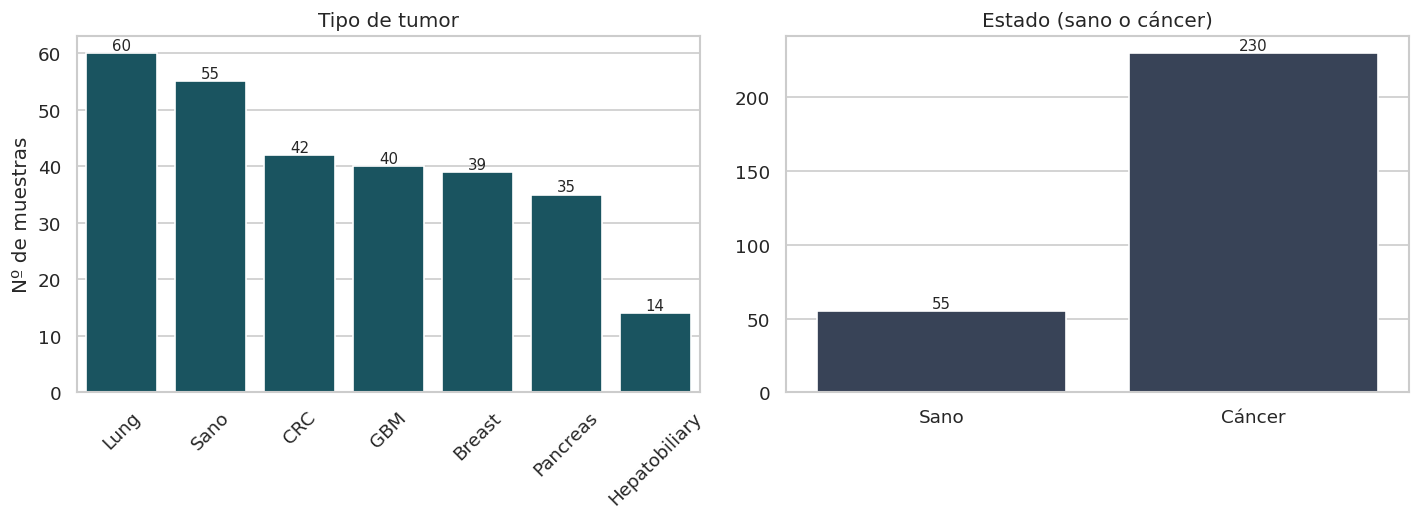

In [19]:
etiqueta_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

print("Distribución multiclase:")
print(etiquetas.value_counts(), "\n")
print("Distribución binaria:")
print(etiqueta_binaria.value_counts(), "\n")

# Razón entre la clase más frecuente y la menos frecuente
conteo = etiquetas.value_counts()
print(f"Razón de desbalance multiclase: {conteo.max() / conteo.min():.1f} a 1")
conteo_bin = etiqueta_binaria.value_counts()
print(f"Razón de desbalance binaria:    {conteo_bin.max() / conteo_bin.min():.1f} a 1")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=etiquetas, order=conteo.index, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Tipo de tumor")
ejes[0].set_xlabel(""); ejes[0].set_ylabel("Nº de muestras")
ejes[0].tick_params(axis="x", rotation=45)

sns.countplot(x=etiqueta_binaria, order=["Sano", "Cáncer"], color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Estado (sano o cáncer)")
ejes[1].set_xlabel(""); ejes[1].set_ylabel("")

for eje in ejes:
    for barra in eje.patches:
        eje.annotate(int(barra.get_height()),
                     (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

Ambas formulaciones presentan un desbalance considerable y de magnitud similar. En la tarea binaria, las 230 muestras de pacientes con cáncer cuadruplican a las 55 de individuos sanos. En la multiclase, el tipo más representado es el cáncer de pulmón, con 60 muestras, mientras que el  hepatobiliar apenas tiene 14, lo que supone una razón de algo más de cuatro a uno entre la clase mayoritaria y la minoritaria.

Esta situación tiene dos consecuencias para el resto del trabajo.
- La primera afecta a la evaluación, ya que la exactitud global resultaría engañosa: un modelo que clasificase todas las muestras como cáncer alcanzaría un 80 % de aciertos sin haber aprendido nada útil, de ahí que la comparación se apoye en métricas que ponderan por igual a todas las clases.
- La segunda afecta al entrenamiento, porque los algoritmos tienden a favorecer a las categorías más frecuentes sin importar las minoritarias. Como no existe una estrategia correctora que funcione mejor en todos los casos, y las muestras sintéticas pueden introducir ruido en datos de alta dimensión, se compararán tres alternativas de forma empírica: no aplicar corrección alguna, ponderar las clases durante el entrenamiento y generar muestras sintéticas mediante SMOTE.

La clase hepatobiliar necesita atención particular, ya que al tener solo 14 muestras, cualquier partición de los datos dejará muy pocos casos disponibles para su evaluación, por lo que las métricas correspondientes a esta categoría estarán sujetas a una variabilidad considerable y deberán interpretarse con cuidado.

Antes de pasar a la siguiente fase, es necesario estudiar la existencia de réplicas.

El conjunto incluye al menos una muestra repetida, es decir, un mismo paciente secuenciado en dos ocasiones. Es necesario identificarla porque, si ambas quedasen repartidas entre entrenamiento y prueba, el modelo se evaluaría con información procedente de un individuo ya visto durante el aprendizaje.

In [20]:
replicas = [c for c in expr.columns if c.endswith("-1") and c[:-2] in expr.columns]
n_individuos = expr.shape[1] - len(replicas)

print("Columnas cuyo nombre acaba en -1:",
      len([c for c in expr.columns if c.endswith("-1")]))
print("De ellas, con la muestra base también presente:", len(replicas))
print("Réplica identificada:", replicas)
print(f"\nMuestras: {expr.shape[1]} | Individuos distintos: {n_individuos}")

Columnas cuyo nombre acaba en -1: 28
De ellas, con la muestra base también presente: 1
Réplica identificada: ['Lung-0020J-1']

Muestras: 285 | Individuos distintos: 284


El criterio se centra en los nombres del depósito de datos, que añade el sufijo -1 al identificador de la muestra repetida, y en la condición adicional de que exista la muestra base correspondiente. Esa segunda condición es la que resulta determinante, ya que en la mayoría de los casos el sufijo forma parte del identificador sin indicar repetición alguna, como ocurre en HD-2-1, para la que no existe ninguna muestra HD-2.

Un criterio basado en nombres depende, sin embargo, de la consistencia de quien depositó los datos, por lo que conviene verificar la réplica a partir de los propios valores de expresión.

In [21]:
for col in ["Lung-0020J", "Lung-0020J-1"]:
    print(f"{col:15s} lecturas: {expr[col].sum():>12,.0f} | "
          f"ceros: {(expr[col] == 0).mean():.1%} | "
          f"genes detectados: {(expr[col] > 0).sum():,}")

Lung-0020J      lecturas:    5,054,795 | ceros: 82.4% | genes detectados: 10,170
Lung-0020J-1    lecturas:      592,866 | ceros: 87.3% | genes detectados: 7,344


Ambas muestras se diferencian en profundidad de secuenciación, con más de ocho veces de diferencia entre una y otra. La muestra repetición (Lung-0020J-1) se sitúa además entre las muestras con menor número de lecturas de todo el conjunto, lo que condiciona cualquier comparación entre sus perfiles, ya que gran parte de los genes ausentes en la segunda no refleja una diferencia biológica, sino la falta de lecturas suficientes para detectarlos.

Por este motivo, la comparación se plantea partiendo de la muestra de menor profundidad, que es la que impone el límite, y se realiza sobre los genes con expresión detectable y en escala logarítmica. Un cálculo previo sobre la matriz completa resultó poco concluyente, ya que los más de cuarenta mil genes con valor nulo en casi todas las muestras introducen ruido, el cual distorsiona el resultado.

In [22]:
# Filtrado y transformación provisionales solo para esta comprobación
cpm_tmp = expr / expr.sum(axis=0) * 1e6
genes_tmp = (cpm_tmp >= 1).sum(axis=1) >= 14
log_cpm = np.log2(cpm_tmp.loc[genes_tmp] + 1)

corr_filt = log_cpm.corr(method="pearson")
np.fill_diagonal(corr_filt.values, np.nan)

print("Correlación de la pareja:", f"{corr_filt.loc['Lung-0020J', 'Lung-0020J-1']:.3f}\n")
print("Cinco muestras más parecidas a Lung-0020J-1:")
print(corr_filt["Lung-0020J-1"].sort_values(ascending=False).head(5).to_string())

Correlación de la pareja: 0.927

Cinco muestras más parecidas a Lung-0020J-1:
Lung-0020J    0.927441
Lung-0040     0.891227
CRC-450       0.880331
Lung-0096     0.877633
Lung-0025J    0.873640


La muestra Lung-0020J es la más parecida a Lung-0020J-1, con una correlación de 0,927 frente al 0,891 de la siguiente muestra candidata, un margen que la separa con claridad del resto del conjunto. Las demás muestras próximas corresponden además, en su mayoría, a pacientes con cáncer de pulmón, lo que indica que el cálculo refleja estructura biológica y no ruido técnico.

In [23]:
# Lo último que falta por comprobar para poder decir si son el mismo paciente es que los metadatos coincidan
filas = metadatos["titulo"].isin(["Blood_Platelets_Lung-20", "Blood_Platelets_Lung-20-1"])
print(pd.concat([metadatos.loc[filas, ["titulo", "gsm"]],
                 caract_df.loc[filas]], axis=1).T.to_string())

                                      189                        190
titulo            Blood_Platelets_Lung-20  Blood_Platelets_Lung-20-1
gsm                            GSM1662723                 GSM1662724
caracteristica_0            tissue: blood              tissue: blood
caracteristica_1  cell type: Thrombocytes    cell type: Thrombocytes
caracteristica_2      patient id: Lung-20      patient id: Lung-20-1
caracteristica_3        cancer type: Lung          cancer type: Lung
caracteristica_4           batch: Batch02             batch: Batch02
caracteristica_5  mutational subclass: wt    mutational subclass: wt


Los metadatos respaldan la conclusión. Ambas muestras comparten tejido, tipo celular, tipo tumoral, subclase mutacional y lote de procesamiento, y sus identificadores en el repositorio son consecutivos. El campo de identificación del paciente las registra con valores distintos, de modo que el depósito no declara de forma explícita que correspondan al mismo individuo, aunque la denominación empleada y la coincidencia del resto de atributos apuntan en esa dirección.

Las 285 muestras del conjunto corresponden, por tanto, a 284 individuos distintos.

Ambas secuenciaciones se mantendrán en el mismo lado de la partición, aplicando un criterio conservador que evita la fuga de información hacia el conjunto de evaluación y cuyo coste, en caso de no tratarse del mismo paciente, se limitaría a una única muestra.

## **Desarrollo de la Fase 2: preparación de los datos**

Objetivo del bloque: convertir la matriz en bruto en un conjunto listo para el modelado, cuidando en cada paso que no se filtre información del conjunto de evaluación. Para ello, se necesitan los siguientes pasos: filtrado de genes poco expresados, reorganización a formato de modelo (transposición de la matriz y separación de variables y objetivo), partición entre entrenamiento y prueba, normalización y estandarización, control de calidad de las muestras y preparación de las estrategias frente al desbalance.

*Nota:* todo cálculo que dependa de los datos, se ajusta únicamente con el conjunto de entrenamiento y se aplica después al de prueba. La única excepción es el filtrado de genes, que se realiza sobre el conjunto completo por no utilizar en ningún momento las etiquetas de clase.

**Filtrado de genes poco expresados**

El análisis exploratorio ha mostrado que la mayor parte de los genes apenas se detecta (44.291 de los 57.736 presentan valor cero en más del 90 % de las muestras). Mantenerlos no aporta capacidad a los modelos, empeora el desajuste entre variables y muestras, y encarece todos los pasos posteriores.

El umbral debe fijarse de forma explícita, ya que la zona intermedia de la distribución impide un corte evidente. El criterio elegido exige dos condiciones simultáneas para conservar un gen: que alcance al menos una lectura por millón, y que lo haga en un mínimo de catorce muestras. Ninguna de las dos basta por sí sola, de modo que se descartan tanto los genes que alcanzan valores altos en muy pocas muestras como aquellos que, pese a aparecer con frecuencia, lo hacen siempre con niveles mínimos.

El hecho de elegir 14 muestras corresponde al tamaño del grupo menos representado, el hepatobiliar. Se escoge ese valor ya que un gen característico de un único tipo tumoral se expresaría únicamente en las muestras de ese grupo y en ninguna otra. Un umbral mayor lo eliminaría precisamente por ser específico, cuando se trata del tipo de gen que interesa conservar. Por debajo de esa cifra, en cambio, no existe ningún grupo que justifique la presencia del gen, por lo que su aparición resulta atribuible al ruido técnico del proceso de secuenciación.

La exigencia se formula en lecturas por millón y no en conteos brutos porque estos últimos dependen de la profundidad de secuenciación. Es decir, una muestra con siete millones de lecturas presenta valores más elevados en todos sus genes que otra con doscientas mil, sin que ello implique mayor expresión. Al expresar el umbral en proporción al total de cada muestra, la exigencia resulta equivalente para todas.

Este filtro se aplica sobre el conjunto completo, antes de la partición, porque en ningún momento utiliza las etiquetas de clase (mide cuánto se expresa cada gen, sin considerar si la muestra procede de un individuo sano o de un paciente con cáncer). No existe, por tanto, riesgo de que el conjunto de evaluación influya en la decisión.

El caso de la selección de características es distinto, porque sí evalúa la relación de cada gen con la clase y deberá realizarse dentro de la validación cruzada.

In [24]:
# Conteos por millón, solo para decidir el filtro (los datos siguen en bruto)
cpm = expr / expr.sum(axis=0) * 1e6

umbral_cpm = 1
min_muestras = int(etiquetas.value_counts().min())   # 14, la clase minoritaria

genes_a_conservar = (cpm >= umbral_cpm).sum(axis=1) >= min_muestras
expr_filtrada = expr.loc[genes_a_conservar]

print(f"Criterio: al menos {umbral_cpm} CPM en {min_muestras} muestras o más\n")
print(f"Genes antes del filtrado: {expr.shape[0]:,}")
print(f"Genes tras el filtrado:   {expr_filtrada.shape[0]:,}")
print(f"Genes descartados:        {expr.shape[0] - expr_filtrada.shape[0]:,} "
      f"({1 - expr_filtrada.shape[0] / expr.shape[0]:.1%})")
print(f"\nDimensiones resultantes: {expr_filtrada.shape}")

Criterio: al menos 1 CPM en 14 muestras o más

Genes antes del filtrado: 57,736
Genes tras el filtrado:   13,343
Genes descartados:        44,393 (76.9%)

Dimensiones resultantes: (13343, 285)


El filtrado reduce la matriz de 57.736 a 13.343 genes, descartando 44.393 variables (un 76,9 % del total).

Con esto, la dimensionalidad del problema disminuye, aunque, se mantiene la condición de que el número de variables sigue superando ampliamente al de muestras, con algo más de trece mil genes frente a las 285 disponibles.

In [25]:
cpm_filtrada = cpm.loc[genes_a_conservar]
print("Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    detectados = (cpm_filtrada[columnas] >= umbral_cpm).sum(axis=0)
    print(f"  {clase:15s} {detectados.median():>7,.0f}")


Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:

  Lung              6,664
  Sano              8,925
  CRC               6,766
  GBM               7,134
  Breast            7,176
  Pancreas          7,156
  Hepatobiliary     7,782


La comprobación por clases descarta que el criterio haya perjudicado a alguna categoría en particular. La mediana de genes detectados se sitúa entre 6.664 y 8.925 según el grupo, valores del mismo orden en todos los casos.

Resulta especialmente importante que el grupo hepatobiliar no quede desfavorecido, con 7.782 genes detectados, ya que su tamaño fue el que sirvió de referencia para fijar el umbral.

El grupo con mayor cantidad de genes detectados es el de los Sanos, ¿puede eso tener que ver con el número de lecturas por muestra?


In [26]:
print("Mediana de lecturas por muestra, según clase:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    print(f"  {clase:15s} {expr[columnas].sum(axis=0).median():>12,.0f}")

Mediana de lecturas por muestra, según clase:

  Lung               2,043,704
  Sano               1,037,596
  CRC                2,329,392
  GBM                1,725,766
  Breast             2,394,606
  Pancreas           2,289,569
  Hepatobiliary      1,909,101



Vemos que las muestras de individuos sanos son las que menos lecturas acumulan por muestra, con una mediana de 1.037.596 frente a los más de dos millones de algunos grupos tumorales, y sin embargo son las que mayor número de genes detectan.

La diferencia no puede atribuirse, por tanto, a una secuenciación más profunda, sino que sugiere un perfil de expresión más repartido entre genes distintos, mientras que en las muestras tumorales una proporción mayor de las lecturas se concentra en un conjunto más reducido. Se trata de una observación exploratoria que no forma parte de los objetivos del trabajo; esta observación resulta coherente con el fenómeno de educación plaquetaria tratado en la literatura del trabajo, según el cual la presencia del tumor altera el perfil transcripcional de la plaqueta.

**Transposición y separación de variables y objetivo**

Los algoritmos de clasificación esperan que cada fila represente una observación y cada columna una variable.

Como la matriz de expresión sigue la dinámica contraria, propia de los ficheros de genómica, debe transponerse. Tras la transposición, cada individuo queda representado por un vector de 13343 valores de expresión, uno por gen.

A esa matriz de variables se asocian dos variables objetivo distintas, correspondientes a las dos tareas planteadas. La primera es binaria y separa a los individuos sin cáncer de aquellos que lo padecen. La segunda es multiclase y distingue entre los seis tipos tumorales presentes en el conjunto; en esta segunda tarea las muestras de individuos sanos quedan excluidas, ya que el objetivo es discriminar el origen del tumor en pacientes que ya han sido identificados como enfermos.

In [27]:
# Transposición: muestras en filas, genes en columnas
X = expr_filtrada.T
X.index.name = "muestra"

# Tarea binaria: sano frente a cáncer (las 285 muestras)
y_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

# Tarea multiclase: tipo de tumor (solo las muestras de cáncer)
muestras_cancer = etiquetas[etiquetas != "Sano"].index
X_multiclase = X.loc[muestras_cancer]
y_multiclase = etiquetas.loc[muestras_cancer]

print(f"Matriz de variables (X): {X.shape[0]} muestras × {X.shape[1]:,} genes\n")

print("Tarea binaria:")
print(f"  X: {X.shape}")
print(y_binaria.value_counts().to_string(), "\n")

print("Tarea multiclase:")
print(f"  X: {X_multiclase.shape}")
print(y_multiclase.value_counts().to_string())

Matriz de variables (X): 285 muestras × 13,343 genes

Tarea binaria:
  X: (285, 13343)
tipo_tumor
Cáncer    230
Sano       55 

Tarea multiclase:
  X: (230, 13343)
tipo_tumor
Lung             60
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14


In [28]:
print("Índices alineados (binaria):   ", X.index.equals(y_binaria.index))
print("Índices alineados (multiclase):", X_multiclase.index.equals(y_multiclase.index))
print("Valores faltantes en X:        ", int(X.isna().sum().sum()))
print("\nPrimeras filas y columnas de X:")
print(X.iloc[:3, :4])

Índices alineados (binaria):    True
Índices alineados (multiclase): True
Valores faltantes en X:         0

Primeras filas y columnas de X:
                     ENSG00000000003  ENSG00000000419  ENSG00000000457  \
muestra                                                                  
3-Breast-Her2-ampl                 0               44               26   
8-Breast-WT                        0               14                1   
10-Breast-Her2-ampl                0               16               14   

                     ENSG00000000460  
muestra                               
3-Breast-Her2-ampl                81  
8-Breast-WT                       98  
10-Breast-Her2-ampl               18  


La matriz queda organizada en 285 filas, una por muestra, y 13.343 columnas, una por gen. Sobre ella se definen las dos variables objetivo. La tarea binaria conserva las 285 muestras, con 230 casos de cáncer frente a 55 controles sanos, mientras que la multiclase trabaja solo con las 230 muestras tumorales: 60 de pulmón, 42 colorrectales, 40 glioblastomas, 39 de mama, 35 de páncreas y 14 hepatobiliares.

La ejecución de la segunda celda de código sirve para ver que los índices de la matriz de variables y de las etiquetas coinciden en ambas tareas y no hay valores ausentes.

**Partición entre entrenamiento y prueba**

La comparación final entre modelos debe realizarse sobre datos que no hayan participado en el entrenamiento ni en el ajuste de hiperparámetros. Se reserva para ello un 20 % de las muestras, proporción que deja suficientes casos para entrenar, dado lo reducido del conjunto, y conserva un grupo de evaluación con un mínimo de representatividad. En la tarea multiclase esa cifra supone apenas tres muestras del grupo hepatobiliar, límite que conviene tener presente al interpretar sus métricas.

La partición se estratifica por clase para que ninguna quede infrarrepresentada por azar. Además, las dos muestras del paciente Lung-0020J deben permanecer en el mismo lado, ya que, tal y como se ha mencionado antes, repartirlas supondría evaluar el modelo con información procedente de un individuo visto durante el entrenamiento.

In [29]:
# Para la tarea binaria
from sklearn.model_selection import train_test_split

replica = ["Lung-0020J", "Lung-0020J-1"]

# Se aparta la réplica antes de repartir y se devuelve después a entrenamiento
sin_replica = X.index.difference(replica)

X_ent_bin, X_pru_bin, y_ent_bin, y_pru_bin = train_test_split(
    X.loc[sin_replica], y_binaria.loc[sin_replica],
    test_size=0.20, stratify=y_binaria.loc[sin_replica], random_state=semilla)

X_ent_bin = pd.concat([X_ent_bin, X.loc[replica]])
y_ent_bin = pd.concat([y_ent_bin, y_binaria.loc[replica]])

print("Tarea binaria")
print(f"  Entrenamiento: {X_ent_bin.shape[0]} muestras")
print(y_ent_bin.value_counts().to_string())
print(f"\n  Prueba: {X_pru_bin.shape[0]} muestras")
print(y_pru_bin.value_counts().to_string())
print("\n¿El individuo estudiado dos veces aparece en el entrenamiento?", all(m in X_ent_bin.index for m in replica))

Tarea binaria
  Entrenamiento: 228 muestras
tipo_tumor
Cáncer    184
Sano       44

  Prueba: 57 muestras
tipo_tumor
Cáncer    46
Sano      11

¿El individuo estudiado dos veces aparece en el entrenamiento? True


In [30]:
# Para la tarea multiclase
sin_replica_multi = X_multiclase.index.difference(replica)

X_ent_multi, X_pru_multi, y_ent_multi, y_pru_multi = train_test_split(
    X_multiclase.loc[sin_replica_multi], y_multiclase.loc[sin_replica_multi],
    test_size=0.20, stratify=y_multiclase.loc[sin_replica_multi],
    random_state=semilla)

X_ent_multi = pd.concat([X_ent_multi, X_multiclase.loc[replica]])
y_ent_multi = pd.concat([y_ent_multi, y_multiclase.loc[replica]])

print("Tarea multiclase")
print(f"  Entrenamiento: {X_ent_multi.shape[0]} muestras")
print(y_ent_multi.value_counts().to_string())
print(f"\n  Prueba: {X_pru_multi.shape[0]} muestras")
print(y_pru_multi.value_counts().to_string())

print("\n¿El individuo estudiado dos veces aparece en el entrenamiento?", all(m in X_ent_multi.index for m in replica))

Tarea multiclase
  Entrenamiento: 184 muestras
tipo_tumor
Lung             48
CRC              34
GBM              32
Breast           31
Pancreas         28
Hepatobiliary    11

  Prueba: 46 muestras
tipo_tumor
Lung             12
CRC               8
GBM               8
Breast            8
Pancreas          7
Hepatobiliary     3

¿El individuo estudiado dos veces aparece en el entrenamiento? True


Se debe terminar comprobando que ninguna muestra ha quedado tanto en el entrenamiento como en el conjunto de prueba.

In [31]:
for nombre, ent, pru in [("binaria", X_ent_bin, X_pru_bin),
                         ("multiclase", X_ent_multi, X_pru_multi)]:
    solapamiento = set(ent.index) & set(pru.index)
    print(f"{nombre:12s} muestras compartidas entre conjuntos: {len(solapamiento)}")

binaria      muestras compartidas entre conjuntos: 0
multiclase   muestras compartidas entre conjuntos: 0


La partición reserva 57 muestras para la evaluación de la tarea binaria y 46 para la multiclase, manteniendo en ambos conjuntos proporciones equivalentes a las del conjunto completo. Las dos secuenciaciones del paciente Lung-0020J quedan en el lado de entrenamiento, y ninguna muestra aparece a la vez en los dos conjuntos.

El reparto es aleatorio, aunque sujeto a la condición de que cada clase conserve su proporción. Sin esa restricción, el azar podría dejar las categorías más pequeñas infrarrepresentadas o incluso ausentes del conjunto de evaluación, algo probable con solo catorce muestras hepatobiliares.

Conviene señalar una limitación del diseño. La comparación final se apoya en una única partición, de modo que los resultados dependen en cierta medida del reparto concreto obtenido. El caso más delicado es el del grupo hepatobiliar, que solo tiene tres muestras en el conjunto de prueba multiclase: un solo acierto o error modifica su sensibilidad en un tercio. Por lo que, para valorar hasta qué punto las conclusiones dependen del reparto, la evaluación final se repetirá con varias semillas distintas, informando de la media y la dispersión de las métricas obtenidas. La selección de modelos, por su parte, se apoya en la validación cruzada realizada sobre el conjunto de entrenamiento, donde cada muestra participa en varias evaluaciones.

**Normalización y estandarización**

Los conteos en bruto no son comparables entre muestras dado que la profundidad de secuenciación varía en más de treinta veces entre la muestra con menos lecturas y la que más tiene.

La corrección habitual consiste en expresar cada valor en lecturas por millón, dividiendo por el total de la muestra. A esa escala se aplica después una transformación logarítmica, que comprime el rango de valores y disminuye el peso de los genes muy expresados, cuya distribución resultaba fuertemente asimétrica. Se suma una unidad antes de transformar para que los ceros no queden indefinidos.

Estas dos operaciones actúan sobre cada muestra por separado, empleando únicamente sus propios valores, de modo que pueden aplicarse a ambos conjuntos sin riesgo de fuga de información. Distinto es el caso de la estandarización, que centra y escala cada gen a partir de su media y su desviación típica. Esos dos estadísticos se calculan sobre el conjunto de datos, por lo que deben obtenerse solo con las muestras de entrenamiento y aplicarse después, sin recalcular, a las de prueba. De lo contrario, la evaluación se contaminaría con información procedente de muestras que el modelo no debería conocer.

In [32]:
def normalizar(matriz):
    cpm = matriz.div(matriz.sum(axis=1), axis=0) * 1e6
    return np.log2(cpm + 1)

X_ent_bin_norm = normalizar(X_ent_bin)
X_pru_bin_norm = normalizar(X_pru_bin)
X_ent_multi_norm = normalizar(X_ent_multi)
X_pru_multi_norm = normalizar(X_pru_multi)

print("Antes de normalizar (conteos brutos):")
print(f"  mínimo {X_ent_bin.to_numpy().min():,.0f} | "
      f"máximo {X_ent_bin.to_numpy().max():,.0f}")
print("\nDespués de normalizar (log2 de CPM + 1):")
print(f"  mínimo {X_ent_bin_norm.to_numpy().min():.2f} | "
      f"máximo {X_ent_bin_norm.to_numpy().max():.2f}")

# El total por muestra debe ser el mismo en todas tras pasar a CPM
totales_cpm = (X_ent_bin.div(X_ent_bin.sum(axis=1), axis=0) * 1e6).sum(axis=1)
print(f"\nTotal de CPM por muestra: mínimo {totales_cpm.min():,.0f} | "
      f"máximo {totales_cpm.max():,.0f}")

Antes de normalizar (conteos brutos):
  mínimo 0 | máximo 1,047,567

Después de normalizar (log2 de CPM + 1):
  mínimo 0.00 | máximo 18.22

Total de CPM por muestra: mínimo 1,000,000 | máximo 1,000,000


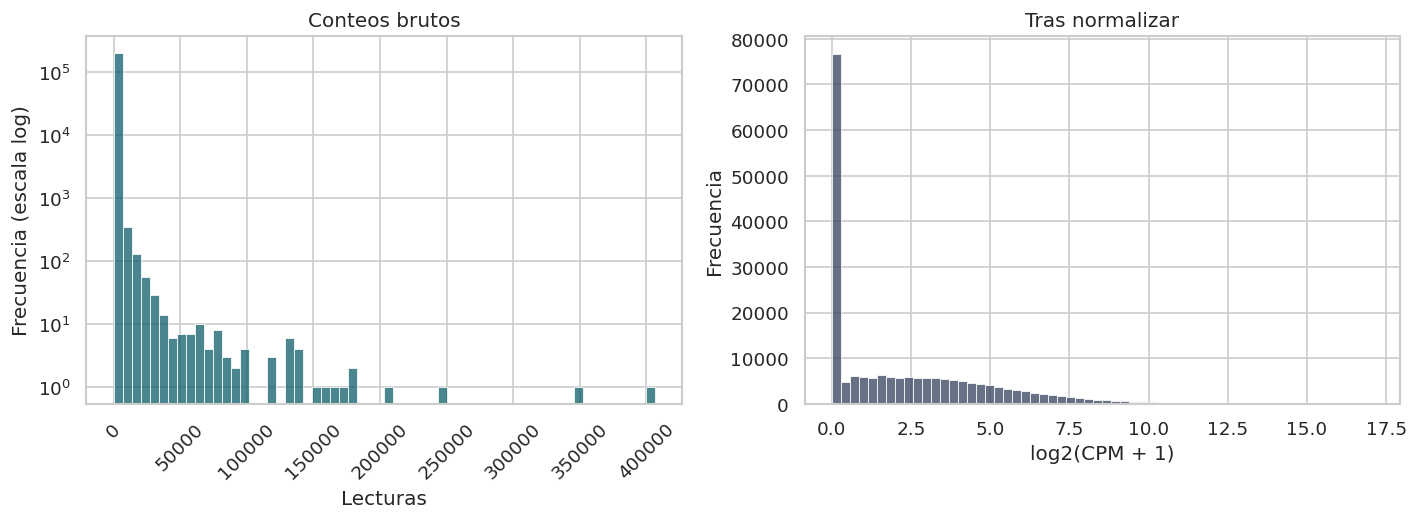

In [33]:
rng = np.random.default_rng(semilla)
muestra_bruta = rng.choice(X_ent_bin.to_numpy().ravel(), size=200_000, replace=False)
muestra_norm = rng.choice(X_ent_bin_norm.to_numpy().ravel(), size=200_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(muestra_bruta, bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_yscale("log")
ejes[0].set_title("Conteos brutos")
ejes[0].set_xlabel("Lecturas"); ejes[0].set_ylabel("Frecuencia (escala log)")
ejes[0].tick_params(axis='x', rotation=45)

sns.histplot(muestra_norm, bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Tras normalizar")
ejes[1].set_xlabel("log2(CPM + 1)"); ejes[1].set_ylabel("Frecuencia")

plt.tight_layout(); plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler

def estandarizar(entrenamiento, prueba):
    escalador = StandardScaler()
    ent = pd.DataFrame(escalador.fit_transform(entrenamiento),
                       index=entrenamiento.index, columns=entrenamiento.columns)
    pru = pd.DataFrame(escalador.transform(prueba),
                       index=prueba.index, columns=prueba.columns)
    return ent, pru, escalador

X_ent_bin_esc, X_pru_bin_esc, escalador_bin = estandarizar(
    X_ent_bin_norm, X_pru_bin_norm)
X_ent_multi_esc, X_pru_multi_esc, escalador_multi = estandarizar(
    X_ent_multi_norm, X_pru_multi_norm)

print("Entrenamiento tras estandarizar:")  # debe dar media 0 y desviación 1
print(f"  media {X_ent_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_ent_bin_esc.to_numpy().std():.3f}")
print("\nPrueba tras aplicar la misma escala:") # no tiene por qué dar 0 y 1
print(f"  media {X_pru_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_pru_bin_esc.to_numpy().std():.3f}")

Entrenamiento tras estandarizar:
  media 0.000 | desviación 1.000

Prueba tras aplicar la misma escala:
  media -0.018 | desviación 1.055


La normalización deja todas las muestras con un total de un millón de lecturas, lo que las hace comparables entre sí con independencia de su profundidad de secuenciación original. Los valores, que en bruto llegaban hasta 1.047.567 lecturas en una sola celda, pasan a moverse en un rango de 0 a 18,22 en escala logarítmica.

El valor de ese máximo, 18,22, equivale a unas 305.000 lecturas por millón, de manera que un único gen concentra cerca del 30 % de todas las lecturas de esa muestra. Esto es común en el transcriptoma plaquetario, donde unos pocos genes muy abundantes acaparan buena parte de la señal (sin la transformación logarítmica, esos genes dominarían por completo cualquier cálculo de distancias o de coeficientes).

Las gráficas muestran el cambio conseguido, se aprecia que la distribución de conteos brutos se concentra por completo junto al cero, con una cola tan larga que solo resulta visible representando la frecuencia en escala logarítmica. Tras normalizar, la distribución se despliega en un rango manejable, manteniendo el pico correspondiente a los valores nulos, pero el resto de la señal se distribuye de forma mucho más gradual entre 0 y 18.

La estandarización deja el conjunto de entrenamiento con media cero y desviación típica uno, tal como se esperaba. El conjunto de prueba, transformado con esos mismos parámetros, presenta una media de -0,018 y una desviación de 1,055. El hecho de que no coincidan exactamente con cero y uno es justamente la señal de que la escala no se ha recalculado con sus datos, ya que si lo hubiera hecho, el conjunto de evaluación habría influido en su propia transformación.

**Control de calidad de las muestras**

En datos de expresión no tiene sentido buscar valores atípicos gen a gen, porque un valor muy alto suele reflejar actividad biológica real, no un error de medida, y la transformación logarítmica ya ha comprimido el rango. Lo que sí conviene detectar son muestras completas cuyo perfil se aparte del resto, ya que una secuenciación deficiente, un ARN degradado o un problema de procesamiento afectan a la muestra entera y no a valores sueltos.

La forma común de verlo es reducir cada muestra a unas pocas dimensiones mediante análisis de componentes principales (PCA) y observar su posición relativa. El interés está en comprobar si la principal fuente de variación responde a diferencias biológicas o a factores técnicos.

Este análisis se realiza únicamente sobre el conjunto de entrenamiento, para no obtener información del conjunto reservado para la evaluación.

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=semilla)
componentes = pca.fit_transform(X_ent_bin_esc)

varianza = pca.explained_variance_ratio_
print("Varianza explicada por componente:")
for i, v in enumerate(varianza[:5], start=1):
    print(f"  CP{i}: {v:.1%}")
print(f"\nAcumulada en 10 componentes: {varianza.sum():.2%}")

pca_df = pd.DataFrame(componentes[:, :2], index=X_ent_bin_esc.index,
                      columns=["CP1", "CP2"])
pca_df["clase"] = etiquetas.loc[pca_df.index]
pca_df["lecturas"] = X_ent_bin.sum(axis=1)

Varianza explicada por componente:
  CP1: 18.4%
  CP2: 5.9%
  CP3: 4.0%
  CP4: 2.2%
  CP5: 1.7%

Acumulada en 10 componentes: 37.67%


La primera componente recoge el 18,4 % de la variación y la segunda el 5,9 %, de forma que entre ambas explican menos de una cuarta parte del total y las diez primeras no alcanzan el 38 %. La variación está, por tanto, muy repartida, algo común cuando se manejan miles de genes que responden a factores diversos.

Estas cifras no bastan para descartar la presencia de efectos técnicos, por lo que es necesario examinar la posición de las muestras según su tipo de tumor y su profundidad de secuenciación.

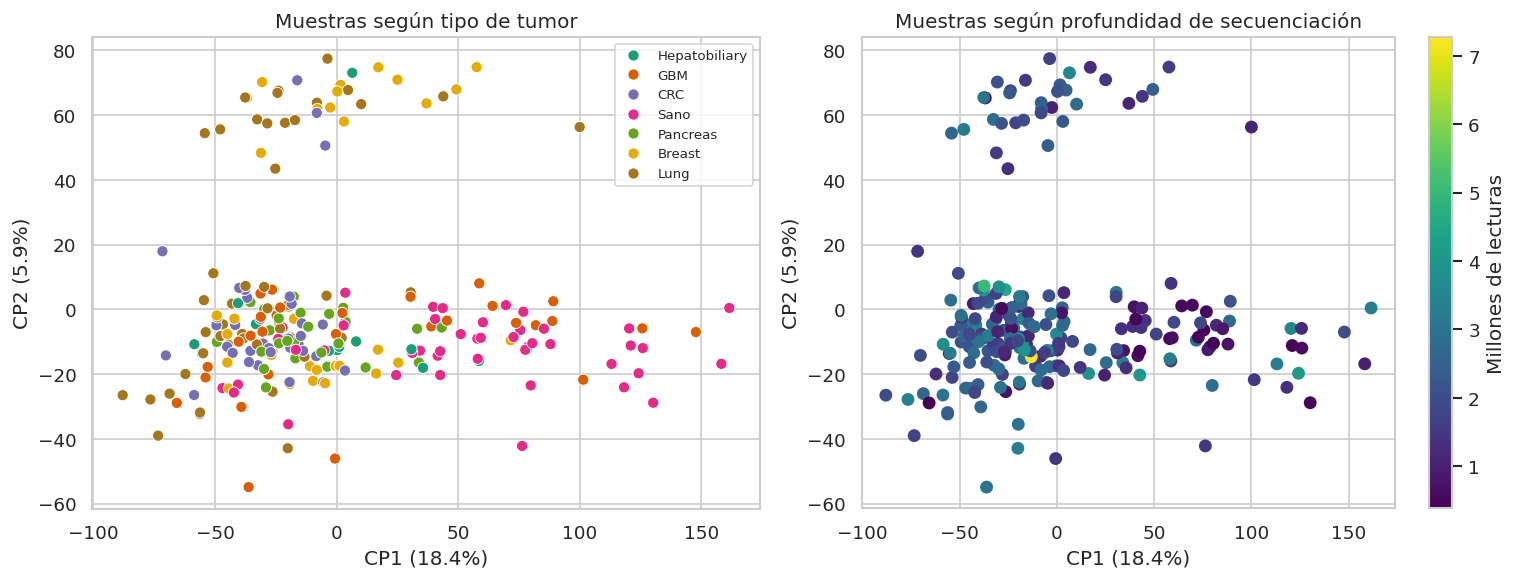

In [36]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=pca_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45, ax=ejes[0])
ejes[0].set_title("Muestras según tipo de tumor")
ejes[0].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[0].set_ylabel(f"CP2 ({varianza[1]:.1%})")
ejes[0].legend(fontsize=8, title=None)

dispersion = ejes[1].scatter(pca_df["CP1"], pca_df["CP2"],
                             c=pca_df["lecturas"] / 1e6, cmap="viridis", s=45)
ejes[1].set_title("Muestras según profundidad de secuenciación")
ejes[1].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[1].set_ylabel(f"CP2 ({varianza[1]:.1%})")
plt.colorbar(dispersion, ax=ejes[1], label="Millones de lecturas")

plt.tight_layout(); plt.show()

La representación por profundidad no muestra ningún gradiente: muestras con menos de un millón de lecturas aparecen mezcladas con otras de más de cuatro millones, lo que confirma que la normalización ha cumplido su función.

Aparece, en cambio, un grupo de muestras claramente separado en la parte superior, que no se explica por la profundidad ni corresponde a un único tipo de tumor. Es por esto que se necesita comprobar si responde al lote de procesamiento (es decir, aquellas registradas en la misma tanda del laboratorio), dato registrado en los metadatos.

In [37]:
def extraer_campo(fila, clave):
    for valor in fila:
        if isinstance(valor, str) and valor.split(":", 1)[0].strip().lower() == clave:
            return valor.split(":", 1)[1].strip()
    return None

lote_meta = caract_df.apply(lambda f: extraer_campo(f, "batch"), axis=1)
print("Lotes registrados en los metadatos:")
print(lote_meta.value_counts(dropna=False).to_string())

Lotes registrados en los metadatos:
Batch03    103
Batch04     87
Batch02     53
Batch06     30
Batch05     10
Batch01      2


In [38]:
# Esto es para identificar de qué tipo son las muestras separadas
codigo_meta = {limpiar_codigo(t.replace("Blood_Platelets_", "").split("-", 1)[1]
                              .replace("ALK", "")): i
               for i, t in enumerate(metadatos["titulo"])}

lote_por_columna = {}
for col in X_ent_bin_esc.index:
    i = codigo_meta.get(codigo_expr(col))
    lote_por_columna[col] = lote_meta.iloc[i] if i is not None else None

pca_df["lote"] = [lote_por_columna.get(m) for m in pca_df.index]

grupo_alto = pca_df["CP2"] > 40
print(f"Muestras separadas en la parte superior (CP2 > 40): {grupo_alto.sum()}\n")
print("Lote de esas muestras:")
print(pca_df.loc[grupo_alto, "lote"].value_counts(dropna=False).to_string())
print("\nClase de esas muestras:")
print(pca_df.loc[grupo_alto, "clase"].value_counts().to_string())

Muestras separadas en la parte superior (CP2 > 40): 33

Lote de esas muestras:
lote
Batch06    24
Batch05     9

Clase de esas muestras:
clase
Lung             16
Breast           13
CRC               3
Hepatobiliary     1


El grupo separado corresponde exactamente a los lotes Batch05 y Batch06 (solo 33 cayeron en el grupo de entrenamiento, el resto en el conjunto de prueba), de manera que la separación responde a un efecto de lote.

Este descubrimiento es importante. El conjunto no incluye ningún control sano, ni ninguna muestra de glioblastoma o de páncreas, reúne 16 casos de pulmón, 13 de mama, 3 colorrectales y 1 hepatobiliar.

Lote y clase están, por tanto, parcialmente confundidos, y un modelo podría aprender a reconocer la procedencia técnica de la muestra en lugar de su perfil biológico. Los métodos habituales de corrección de efectos de lote asumen que este es independiente de la variable objetivo, condición que aquí no se cumple, de modo que aplicarlos podría eliminar señal biológica junto con la técnica. Se opta por documentar la limitación y comprobar más adelante si los genes que sustentan las predicciones coinciden con los que distinguen entre lotes.

In [39]:
# Distancia de cada muestra al centro de la nube, en las diez componentes
centro = componentes.mean(axis=0)
distancias = pd.Series(np.linalg.norm(componentes - centro, axis=1),
                       index=X_ent_bin_esc.index).sort_values(ascending=False)

umbral = distancias.mean() + 3 * distancias.std()
print(f"Umbral (media + 3 desviaciones típicas): {umbral:.1f}\n")

resumen = pd.DataFrame({
    "distancia": distancias.head(10).round(1),
    "clase": etiquetas.loc[distancias.head(10).index],
    "lecturas": X_ent_bin.sum(axis=1).loc[distancias.head(10).index],
})
print("Diez muestras más alejadas del centro:\n")
print(resumen.to_string())
print(f"\nMuestras por encima del umbral: {(distancias > umbral).sum()}")

Umbral (media + 3 desviaciones típicas): 152.6

Diez muestras más alejadas del centro:

                     distancia clase  lecturas
muestra                                       
HD-45-1                  178.0  Sano   3267506
VU280-GBM                174.8   GBM   1439266
HD-38-2                  163.0  Sano    989811
GBM-440                  154.9   GBM   1979592
GBM-486                  138.8   GBM   1177855
MGH-NSCLC-L12-TR478      138.2  Lung   1050839
HD-1                     138.1  Sano   1347946
HD-46-1                  137.9  Sano   4087549
HD-48-1                  136.3  Sano    448086
HD-51-1                  136.1  Sano    618318

Muestras por encima del umbral: 4


Cuatro muestras superan el umbral de tres desviaciones típicas respecto al centro de la nube: dos controles sanos y dos glioblastomas.

En el conjunto de las diez más alejadas, seis son controles sanos y tres glioblastomas, lo que apunta a una mayor variabilidad interna de esos dos grupos antes que a fallos técnicos. Tampoco se aprecia relación con la profundidad de secuenciación, ya que entre las diez figuran tanto muestras de apenas 448.086 lecturas como otras que superan los cuatro millones.

Ninguna muestra se elimina porque con 285 muestras disponibles cada caso cuenta, y descartar alguno a partir de una distancia calculada sobre componentes que explican poco más de un tercio de la variación, sería una decisión mal tomada.

El análisis anterior se ha realizado sobre el conjunto de entrenamiento de la tarea binaria, que incluye muestras de todos los tipos tumorales además de los controles. Las conclusiones sobre calidad son extensibles a la tarea multiclase, ya que tanto las muestras anómalas como el efecto de lote son propiedades de las muestras y no dependen de la etiqueta que se les asigne.

Sin embargo, es buena idea repetir la representación empleando únicamente las muestras tumorales, con la finalidad de comprobar si los seis tipos de tumor presentan alguna separación apreciable antes de aplicar ningún método de selección.

Varianza explicada (solo muestras tumorales):
  CP1: 14.1%
  CP2: 6.8%
  CP3: 4.3%


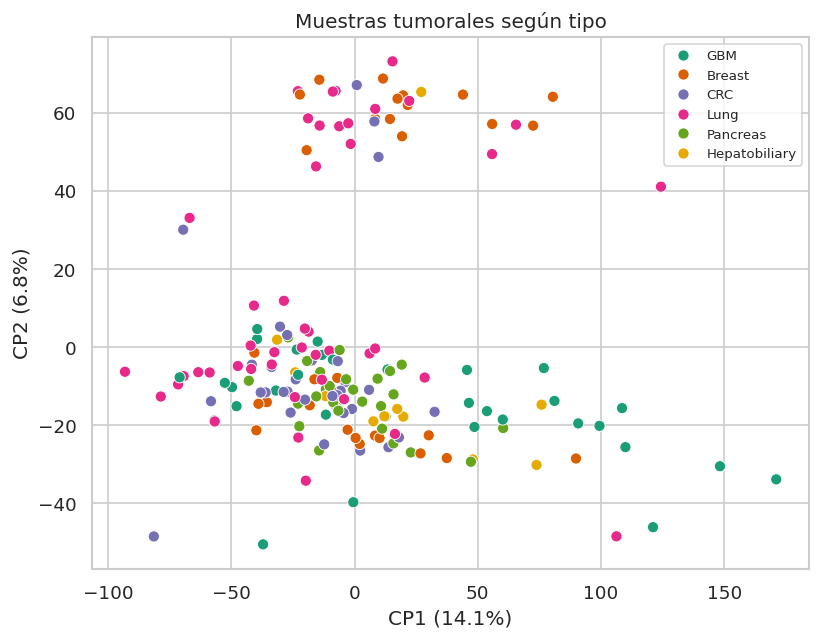

In [40]:
pca_multi = PCA(n_components=10, random_state=semilla)
comp_multi = pca_multi.fit_transform(X_ent_multi_esc)
var_multi = pca_multi.explained_variance_ratio_

pca_multi_df = pd.DataFrame(comp_multi[:, :2], index=X_ent_multi_esc.index,
                            columns=["CP1", "CP2"])
pca_multi_df["clase"] = y_ent_multi

print("Varianza explicada (solo muestras tumorales):")
for i, v in enumerate(var_multi[:3], start=1):
    print(f"  CP{i}: {v:.1%}")

plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=pca_multi_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45)
plt.title("Muestras tumorales según tipo")
plt.xlabel(f"CP1 ({var_multi[0]:.1%})"); plt.ylabel(f"CP2 ({var_multi[1]:.1%})")
plt.legend(fontsize=8, title=None)
plt.tight_layout(); plt.show()

Al repetir el análisis solo con las 184 muestras tumorales del conjunto de entrenamiento, el resultado es que los seis tipos de tumor no se separan. En la nube central aparecen mezclados, de modo que dos muestras próximas en el gráfico pueden pertenecer a tumores distintos. Solo se aprecia una leve tendencia de las muestras de pulmón a situarse hacia la izquierda, que es insuficiente para distinguirlas del resto. Además, vuelve a verse el grupo desplazado hacia arriba, que corresponde de nuevo a los lotes Batch05 y Batch06.

Las dos primeras componentes recogen aquí el 14,1 % y el 6,8 % de la variación, cifras algo menores que en el conjunto completo, lo que resulta lógico al haber excluido a los controles sanos, cuyo perfil era el más diferenciado.

Este resultado no invalida la tarea multiclase, pero muestra que será más difícil que la binaria, ya que las diferencias entre un cáncer de mama y uno de páncreas existen, pero afectan a unos pocos genes y quedan tapadas por la variación del resto. De ahí la necesidad de aplicar métodos de selección de características antes del modelado, puesto que, a diferencia del análisis de componentes principales, estos sí utilizan las etiquetas y pueden localizar los genes que separan las clases, aunque su contribución a la variación total sea pequeña.

**Preparación de las estrategias frente al desbalance de las clases**

El desbalance se trata comparando tres alternativas en lugar de escoger una sola. La primera consiste en no aplicar corrección alguna, y sirve de referencia para valorar si las demás aportan algo. La segunda pondera las clases durante el entrenamiento, penalizando más los errores cometidos sobre las categorías minoritarias sin modificar los datos. La tercera genera muestras sintéticas de las clases pequeñas mediante SMOTE, interpolando entre vecinos próximos.

El orden en que se encadenan las operaciones resulta determinante. Si el reequilibrado se aplicase antes de dividir los datos, las muestras sintéticas generadas a partir del conjunto de entrenamiento podrían acabar evaluándose como si fueran casos nuevos, y el rendimiento saldría inflado. Para evitarlo se emplea la estructura de flujo de imbalanced-learn, que aplica el remuestreo solo a la parte de entrenamiento de cada pliegue y deja intacta la de evaluación.

In [41]:
from imblearn.pipeline import Pipeline as PipelineDesbalance
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

def construir_flujo(modelo, estrategia):
    """Encadena escalado, reequilibrado (si procede) y modelo."""
    pasos = [("escalado", StandardScaler())]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

estrategias = ["ninguna", "ponderacion", "smote"]

In [42]:
# SMOTE genera muestras nuevas interpolando entre las vecinas más próximas de cada clase, por lo que una clase necesita al menos tantas muestras como vecinas se le pidan, más una.
# Dentro de la validación cruzada cada pliegue entrena con solo cuatro quintas partes de los datos, así que se comprueba que la clase más pequeña siga teniendo suficientes en ese caso.
n_pliegues = 5
k_vecinos = 5

for nombre, y in [("binaria", y_ent_bin), ("multiclase", y_ent_multi)]:
    minima = y.value_counts().min()
    clase_min = y.value_counts().idxmin()
    en_pliegue = int(minima * (n_pliegues - 1) / n_pliegues)
    print(f"{nombre:11s} clase menor: {clase_min} ({minima} muestras) -> "
          f"~{en_pliegue} al entrenar en cada pliegue "
          f"{'(suficiente)' if en_pliegue > k_vecinos else '(INSUFICIENTE)'}")

binaria     clase menor: Sano (44 muestras) -> ~35 al entrenar en cada pliegue (suficiente)
multiclase  clase menor: Hepatobiliary (11 muestras) -> ~8 al entrenar en cada pliegue (suficiente)


In [43]:
# Se muestra qué hace SMOTE sobre el conjunto de entrenamiento completo
muestreador = SMOTE(random_state=semilla, k_neighbors=5)

for nombre, X_datos, y in [("Binaria", X_ent_bin_norm, y_ent_bin),
                           ("Multiclase", X_ent_multi_norm, y_ent_multi)]:
    _, y_remuestreado = muestreador.fit_resample(X_datos, y)
    print(f"{nombre}:")
    print("  antes: ", y.value_counts().to_dict())
    print("  después:", pd.Series(y_remuestreado).value_counts().to_dict(), "\n")

Binaria:
  antes:  {'Cáncer': 184, 'Sano': 44}
  después: {'Cáncer': 184, 'Sano': 184} 

Multiclase:
  antes:  {'Lung': 48, 'CRC': 34, 'GBM': 32, 'Breast': 31, 'Pancreas': 28, 'Hepatobiliary': 11}
  después: {'GBM': 48, 'Breast': 48, 'CRC': 48, 'Lung': 48, 'Pancreas': 48, 'Hepatobiliary': 48} 



Las tres estrategias quedan preparadas dentro de un mismo flujo, junto con el escalado, de modo que todas las operaciones que dependen de los datos se recalculen en cada pliegue de la validación cruzada.

La comprobación previa confirma que SMOTE puede aplicarse en ambas tareas, siendo el caso más ajustado es el del grupo hepatobiliar, que con 11 muestras de entrenamiento conserva unas 8 en cada pliegue, suficientes para el método aunque con margen pequeño.

El efecto del remuestreo equipara todas las clases a la más numerosa. En la tarea binaria los 44 controles sanos crecen hasta los 184 casos de cáncer, y en la multiclase todas las categorías alcanzan las 48 muestras de la clase de pulmón. Esto supone que más de tres cuartas partes de las muestras de los pacientes con cáncer hepatobiliar, pasarían a ser sintéticas, construidas a partir de once casos reales. Esa proporción justifica que la estrategia se someta a comparación en lugar de asumirse como beneficiosa, ya que interpolar entre tan pocos ejemplos en un espacio de más de trece mil dimensiones puede añadir más ruido que información.

## **Desarrollo de la Fase 3: modelado**

Objetivo del bloque: reducir el número de variables mediante selección de características, comparar de forma sistemática cinco algoritmos de clasificación cruzados con las tres estrategias frente al desbalance, y afinar los hiperparámetros de las combinaciones con más potencial.

*Nota:* la selección de características utiliza las etiquetas, por lo que se realiza dentro de cada pliegue de la validación cruzada y nunca sobre el conjunto completo.

**Selección de características**

Quedan 13.343 genes, de manera que el desajuste entre dimensiones sigue siendo la principal dificultad. El filtrado de la fase anterior eliminó los genes sin expresión detectable, pero no distingue cuáles resultan útiles para separar las clases.

Esa distinción exige comparar cada gen con la etiqueta, lo que convierte la selección en un paso supervisado y obliga a realizarla dentro de la validación cruzada. Si se hiciera antes, sobre todo el conjunto de entrenamiento, los genes elegidos se habrían escogido sabiendo cómo se comportan en las muestras que después servirán para evaluar cada pliegue, y el rendimiento resultaría optimista.

El método empleado es un filtro univariante que ordena los genes según el estadístico F del análisis de varianza, midiendo hasta qué punto cada uno separa las medias de las clases. Se ha escogido por su bajo coste de cálculo, necesario al tener que repetirse en cada pliegue y para cada combinación de la rejilla. El número de genes a conservar no se fija de antemano, sino que se prueban varios valores y se decide con los resultados.

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif

def construir_flujo(modelo, estrategia, k_genes):
    """
    Encadena escalado, selección de genes, reequilibrado y modelo.
    El orden importa: la selección va antes del remuestreo, de modo que SMOTE interpola en un espacio de pocas dimensiones y no sobre los 13.343 genes.
    """
    pasos = [("escalado", StandardScaler()),
             ("seleccion", SelectKBest(f_classif, k=k_genes))]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

Queda por decidir cuántos genes conservar. Para ello, se prueban varios valores y se compara el rendimiento obtenido mediante validación cruzada. La exploración se realiza con regresión logística y sin corrección del desbalance, ya que su finalidad es acotar un rango razonable y no comparar modelos; cruzar el número de genes con las quince combinaciones de la rejilla multiplicaría el coste sin aportar información útil.

En la tarea binaria se incluye además el conjunto completo de 13.343 genes, que equivale a no seleccionar y sirve como referencia para saber si la selección aporta algo.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

# En la binaria se llega hasta el total de genes; en la multiclase no es
# necesario, ya que el rendimiento no crece a partir de unos pocos miles.
exploracion = {
    "binaria":    (X_ent_bin_norm,   y_ent_bin,   [50, 100, 250, 500, 1000, 2000, 5000, 10000, 13343]),
    "multiclase": (X_ent_multi_norm, y_ent_multi, [50, 100, 250, 500, 1000, 2000, 5000]),
}

resultados_k = []
for tarea, (X_datos, y, valores_k) in exploracion.items():
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv,
                            scoring="balanced_accuracy", n_jobs=-1)
        resultados_k.append({"tarea": tarea, "k": k,
                             "media": p.mean(), "desviacion": p.std()})

tabla_k = pd.DataFrame(resultados_k)

for tarea in exploracion:
    sub = tabla_k[tabla_k["tarea"] == tarea]
    print(f"{tarea.upper()}")
    print(sub[["k", "media", "desviacion"]].round(3).to_string(index=False), "\n")

BINARIA
    k  media  desviacion
   50  0.814       0.052
  100  0.819       0.032
  250  0.812       0.054
  500  0.861       0.076
 1000  0.853       0.088
 2000  0.889       0.072
 5000  0.898       0.069
10000  0.917       0.053
13343  0.917       0.056 

MULTICLASE
   k  media  desviacion
  50  0.476       0.085
 100  0.528       0.073
 250  0.557       0.071
 500  0.565       0.055
1000  0.576       0.059
2000  0.529       0.109
5000  0.558       0.135 



Las cifras obtenidas presentan una dispersión considerable entre pliegues, de modo que las diferencias pequeñas entre configuraciones cercanas podrían deberse al azar. Para distinguir qué tendencias son reales, la exploración se ha repetido con una partición distinta, y si el orden entre configuraciones se mantiene, la diferencia es consistente, pero si se invierte, se trata de ruido.

In [46]:
cv_alternativa = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla + 1)

verificacion = {
    "binaria":    (X_ent_bin_norm,   y_ent_bin,   [1000, 5000, 13343]),
    "multiclase": (X_ent_multi_norm, y_ent_multi, [500, 1000, 2000]),
}

for tarea, (X_datos, y, valores_k) in verificacion.items():
    print(f"{tarea.upper()} (segunda partición)")
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv_alternativa,
                            scoring="balanced_accuracy", n_jobs=-1)
        print(f"  k={k:6d}  {p.mean():.3f} ± {p.std():.3f}")
    print()

BINARIA (segunda partición)
  k=  1000  0.850 ± 0.130
  k=  5000  0.878 ± 0.120
  k= 13343  0.903 ± 0.100

MULTICLASE (segunda partición)
  k=   500  0.596 ± 0.089
  k=  1000  0.570 ± 0.074
  k=  2000  0.586 ± 0.075



Se observan dos comportamientos distintos según la tarea.

- En la binaria, el rendimiento aumenta de forma sostenida conforme se conservan más genes, desde 0,814 con cincuenta hasta 0,917 con el conjunto completo, sin que aparezca ningún máximo intermedio. El orden entre configuraciones se mantiene al repetir la validación cruzada con una partición distinta, de modo que el filtro univariante no localiza ningún subconjunto que supere al total.

- En la multiclase el comportamiento es otro. Los valores comprendidos entre 500 y 2000 genes son similares, siendo la selección de 1000 la que mejores resultados consigue. Al repetir la validación cruzada con otra partición, el orden entre esas configuraciones se invierte por completo, lo que confirma que las diferencias observadas responden a la variabilidad del procedimiento y no a una ventaja real de ninguna de ellas. Solo se sostiene que con cincuenta genes el rendimiento es claramente inferior.

Por tanto, se fijan 5000 genes para la tarea binaria y 1000 para la multiclase. La decisión no se apoya en una mejora del rendimiento, que no se produce en ningún caso, sino en dos razones: la primera es práctica, ya que la rejilla de quince combinaciones debe entrenarse repetidamente y reducir el número de variables abarata el cálculo; la segunda responde a uno de los objetivos del trabajo, puesto que identificar los genes característicos de cada tipo de cáncer supone acotar el conjunto a un tamaño interpretable.

La selección univariante cumple entonces una función de prefiltrado, mientras que la reducción a una firma génica reducida e interpretable se aborda al final del trabajo, aplicando regularización L1 sobre el modelo finalmente seleccionado, procedimiento que evalúa los genes de forma conjunta y no uno a uno.

In [47]:
# Valores de prefiltrado que se emplearán en la rejilla de la fase siguiente
k_binaria = 5000
k_multiclase = 1000

**Comparación de la rejilla de combinaciones**

El núcleo del trabajo es la comparación de cinco algoritmos cruzados con las tres estrategias frente al desbalance, lo que da lugar a quince combinaciones por tarea. Todas se evalúan sobre los mismos datos, con la misma partición de validación cruzada y las mismas métricas, de modo que las diferencias observadas se deban a la combinación y no al procedimiento.

Esta primera comparación usa los hiperparámetros por defecto de cada algoritmo. Su finalidad no es obtener el mejor resultado posible, sino descartar las combinaciones que quedan claramente por detrás antes de afinarlas. El ajuste fino se reserva para las más prometedoras.

Es importante saber que la ponderación de clases no está disponible del mismo modo en todos los algoritmos. La regresión logística, la máquina de vectores soporte y el bosque aleatorio admiten un parámetro que reequilibra el peso de cada clase durante el entrenamiento. Sin embargo, los k vecinos más próximos carecen de él, por lo que se emplea en su lugar el ponderado por distancia, alternativa que favorece a las muestras cercanas y disminuye en parte el dominio de la clase mayoritaria, aunque no resulta equivalente. Además, el gradient boosting lo resuelve mediante pesos asignados a cada muestra en función de la frecuencia de su clase.

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

def crear_modelo(nombre, estrategia):
    """Devuelve el modelo configurado según la estrategia de desbalance."""
    ponderar = (estrategia == "ponderacion")
    if nombre == "regresion_logistica":
        return LogisticRegression(max_iter=2000, random_state=semilla,
                                  class_weight="balanced" if ponderar else None)
    if nombre == "knn":
        # No admite ponderación de clases; se usa el ponderado por distancia
        return KNeighborsClassifier(weights="distance" if ponderar else "uniform")
    if nombre == "svm":
        return SVC(random_state=semilla, probability=True,
                   class_weight="balanced" if ponderar else None)
    if nombre == "random_forest":
        return RandomForestClassifier(random_state=semilla, n_jobs=-1,
                                      class_weight="balanced" if ponderar else None)
    if nombre == "xgboost":
        # La ponderación se aplica por muestra en el momento de entrenar
        return XGBClassifier(random_state=semilla, n_jobs=-1,
                             eval_metric="logloss", verbosity=0)

modelos = ["regresion_logistica", "knn", "svm", "random_forest", "xgboost"]
estrategias = ["ninguna", "ponderacion", "smote"]

Cada combinación se evalúa mediante validación cruzada estratificada de cinco pliegues sobre el conjunto de entrenamiento. Se registran varias métricas a la vez: la exactitud balanceada, que da el mismo peso a cada clase y sirve de criterio principal; la puntuación F1 promediada por clase; y el área bajo la curva ROC, que resume la capacidad de separación independientemente del umbral escogido.

El conjunto de prueba no interviene en ningún momento de esta comparación.

In [49]:
from sklearn.model_selection import cross_validate
import time

def evaluar_rejilla(X_datos, y, k_genes, multiclase):
    codificador = LabelEncoder()
    y_cod = pd.Series(codificador.fit_transform(y), index=y.index)

    metricas = ["balanced_accuracy", "f1_macro",
                "roc_auc_ovr" if multiclase else "roc_auc"]
    filas = []
    for nombre in modelos:
        for estrategia in estrategias:
            inicio = time.time()
            flujo = construir_flujo(crear_modelo(nombre, estrategia),
                                    estrategia, k_genes)
            # XGBoost necesita etiquetas numéricas; el resto acepta ambas
            objetivo = y_cod if nombre == "xgboost" else y
            ajuste = {}
            if nombre == "xgboost" and estrategia == "ponderacion":
                ajuste["modelo__sample_weight"] = compute_sample_weight("balanced", y_cod)

            resultado = cross_validate(flujo, X_datos, objetivo, cv=cv,
                                       scoring=metricas, n_jobs=-1,
                                       params=ajuste if ajuste else None)
            filas.append({
                "modelo": nombre, "estrategia": estrategia,
                "exactitud_balanceada": resultado["test_balanced_accuracy"].mean(),
                "desviacion": resultado["test_balanced_accuracy"].std(),
                "f1_macro": resultado["test_f1_macro"].mean(),
                "auc": resultado[f"test_{metricas[2]}"].mean(),
                "segundos": time.time() - inicio,
            })
            print(f"  {nombre:20s} {estrategia:12s} "
                  f"{filas[-1]['exactitud_balanceada']:.3f} "
                  f"({filas[-1]['segundos']:.0f}s)")
    return pd.DataFrame(filas), codificador

print("TAREA BINARIA")
rejilla_bin, cod_bin = evaluar_rejilla(X_ent_bin_norm, y_ent_bin, k_binaria, False)
print("\nTAREA MULTICLASE")
rejilla_multi, cod_multi = evaluar_rejilla(X_ent_multi_norm, y_ent_multi,
                                           k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ninguna      0.898 (2s)
  regresion_logistica  ponderacion  0.917 (2s)
  regresion_logistica  smote        0.917 (2s)
  knn                  ninguna      0.634 (2s)
  knn                  ponderacion  0.634 (4s)
  knn                  smote        0.882 (2s)
  svm                  ninguna      0.838 (3s)
  svm                  ponderacion  0.851 (3s)
  svm                  smote        0.870 (8s)
  random_forest        ninguna      0.835 (4s)
  random_forest        ponderacion  0.830 (4s)
  random_forest        smote        0.856 (7s)
  xgboost              ninguna      0.876 (15s)
  xgboost              ponderacion  0.879 (17s)
  xgboost              smote        0.870 (50s)

TAREA MULTICLASE
  regresion_logistica  ninguna      0.576 (3s)
  regresion_logistica  ponderacion  0.579 (3s)
  regresion_logistica  smote        0.576 (5s)
  knn                  ninguna      0.461 (3s)
  knn                  ponderacion  0.497 (2s)
  knn                  sm

A pesar de que la exactitud balanceada sea importante, también se han de tener en cuenta las otras métricas.

In [50]:
for nombre, tabla in [("BINARIA", rejilla_bin), ("MULTICLASE", rejilla_multi)]:
    print(f"{nombre} — ordenada por exactitud balanceada y, en caso de empate, por AUC\n")
    print(tabla.sort_values(["exactitud_balanceada", "auc"], ascending=False)
          .round(3).to_string(index=False), "\n")

BINARIA — ordenada por exactitud balanceada y, en caso de empate, por AUC

             modelo  estrategia  exactitud_balanceada  desviacion  f1_macro   auc  segundos
regresion_logistica       smote                 0.917       0.056     0.921 0.978     2.419
regresion_logistica ponderacion                 0.917       0.056     0.921 0.975     2.101
regresion_logistica     ninguna                 0.898       0.069     0.911 0.978     2.148
                knn       smote                 0.882       0.040     0.797 0.926     2.035
            xgboost ponderacion                 0.879       0.066     0.873 0.960    16.535
            xgboost     ninguna                 0.876       0.069     0.882 0.968    14.572
            xgboost       smote                 0.870       0.077     0.870 0.964    50.473
                svm       smote                 0.870       0.062     0.867 0.952     7.789
      random_forest       smote                 0.856       0.075     0.854 0.940     7.434
     

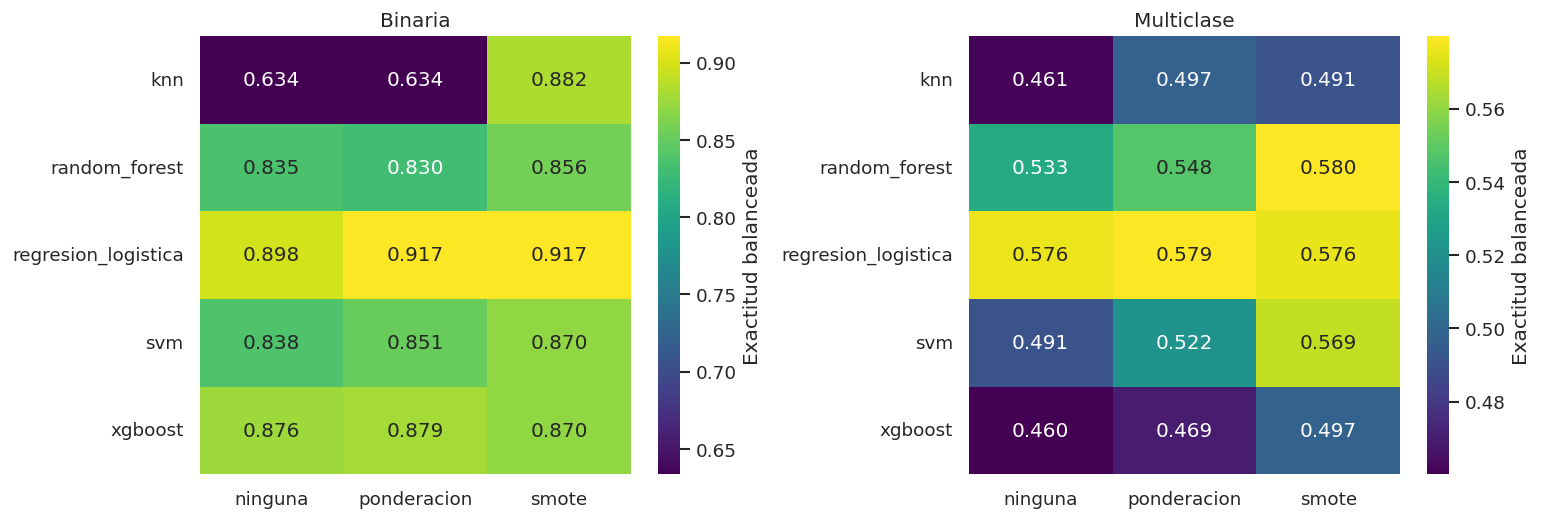

In [51]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, (nombre, tabla) in zip(ejes, [("Binaria", rejilla_bin),
                                       ("Multiclase", rejilla_multi)]):
    matriz = tabla.pivot(index="modelo", columns="estrategia",
                         values="exactitud_balanceada")
    sns.heatmap(matriz, annot=True, fmt=".3f", cmap="viridis", ax=eje,
                cbar_kws={"label": "Exactitud balanceada"})
    eje.set_title(nombre); eje.set_xlabel(""); eje.set_ylabel("")
plt.tight_layout(); plt.show()

En la tarea binaria la regresión logística se impone con diferencia, alcanzando una exactitud balanceada de 0,917 tanto con ponderación de clases como con SMOTE, frente al 0,879 si no se usa ninguna técnica frente al desbalance. El resultado coincide con el obtenido por Jopek et al. (2024) sobre datos de la misma naturaleza, donde un modelo lineal sencillo superó a métodos considerablemente más complejos.

Las dos variantes de la regresión logística quedan empatadas en la métrica principal y difieren en 0.003 de área bajo la curva, diferencia irrelevante frente a una desviación típica de 0,056 entre pliegues. Por lo que, aplicar corrección del desbalance sí aporta algo respecto a no aplicarla, aunque la mejora, de dos centésimas, tampoco resulta concluyente por sí sola.

El método de los k vecinos más próximos queda en último lugar con una diferencia notable, con 0,634 sin remuestreo frente al 0,882 que alcanza al aplicar SMOTE. Esto ocurre porque con miles de variables, las distancias entre muestras tienden a igualarse y el criterio de proximidad pierde capacidad discriminativa. Ese mismo fenómeno explica que ponderar los vecinos por distancia no modifique ningún resultado en la tarea binaria, ya que los pesos apenas varían cuando todas las distancias son parecidas; en la multiclase, con más clases en juego y por tanto más votaciones ajustadas, sí produce un efecto más notable.

La tarea multiclase presenta una situación distinta. Los valores son considerablemente inferiores, con un máximo de 0,580 para el random forest con SMOTE, seguido de la regresión logística con 0,579 y 0,576. Las diferencias entre las tres primeras combinaciones son de milésimas y quedan muy por debajo de sus desviaciones típicas, que varían entre 0,058 y 0,101, de modo que no puede afirmarse que ninguna supere a las demás.

Es importante señalar que la regresión logística presenta la menor dispersión de todas ellas, lo que indica un comportamiento más estable entre particiones.

Por último, destaca el hecho de que el remuestreo mediante SMOTE resulta beneficioso en la mayoría de combinaciones de la tarea multiclase, mientras que en la binaria su efecto es más discreto, salvo en los k vecinos más próximos, donde resulta determinante.

El número de combinaciones que pasan al ajuste de hiperparámetros no se fija a ojo, sino que se escoge en función de la dispersión de los resultados.

Se calcula el error estándar de la mejor combinación, dividiendo su desviación típica entre la raíz del número de pliegues, y se conservan todas aquellas cuya media se sitúe dentro de esa distancia. Esto se basa en que, a menos de un error estándar de diferencia, no se puede afirmar que una combinación sea peor que otra, de manera que descartarla supondría dar por buena una diferencia que los datos no sostienen.

A este criterio se le añade un detalle: tiene que haber un mínimo de cuatro combinaciones, para garantizar que la comparación final no quede excesivamente reducida.

In [52]:
def seleccionar_candidatos(tabla, n_pliegues=5, maximo_por_modelo=3, minimo=4):
    """Combinaciones dentro de un error estándar de la mejor, con tope por
    algoritmo para evitar afinar el mismo modelo repetidamente."""
    tabla = tabla.copy()
    tabla["error_estandar"] = tabla["desviacion"] / np.sqrt(n_pliegues)
    mejor = tabla["exactitud_balanceada"].max()
    umbral = mejor - tabla.loc[tabla["exactitud_balanceada"].idxmax(), "error_estandar"]

    ordenada = tabla.sort_values("exactitud_balanceada", ascending=False)
    dentro = ordenada[ordenada["exactitud_balanceada"] >= umbral]

    # Tope por algoritmo
    elegidas = dentro.groupby("modelo").head(maximo_por_modelo)

    # Si quedan menos del mínimo, se completa con las siguientes mejores
    if len(elegidas) < minimo:
        resto = ordenada.drop(elegidas.index)
        resto = resto.groupby("modelo").head(maximo_por_modelo)
        elegidas = pd.concat([elegidas, resto.head(minimo - len(elegidas))])

    print(f"Mejor: {mejor:.3f} | umbral (un error estándar): {umbral:.3f}")
    print(f"Dentro del umbral: {len(dentro)} | seleccionadas: {len(elegidas)}\n")
    return elegidas.sort_values("exactitud_balanceada", ascending=False)

print("BINARIA")
candidatos_bin = seleccionar_candidatos(rejilla_bin)
print(candidatos_bin[["modelo", "estrategia", "exactitud_balanceada",
                      "desviacion"]].round(3).to_string(index=False))

print("\nMULTICLASE")
candidatos_multi = seleccionar_candidatos(rejilla_multi)
print(candidatos_multi[["modelo", "estrategia", "exactitud_balanceada",
                        "desviacion"]].round(3).to_string(index=False))

BINARIA
Mejor: 0.917 | umbral (un error estándar): 0.892
Dentro del umbral: 3 | seleccionadas: 4

             modelo  estrategia  exactitud_balanceada  desviacion
regresion_logistica ponderacion                 0.917       0.056
regresion_logistica       smote                 0.917       0.056
regresion_logistica     ninguna                 0.898       0.069
                knn       smote                 0.882       0.040

MULTICLASE
Mejor: 0.580 | umbral (un error estándar): 0.534
Dentro del umbral: 6 | seleccionadas: 6

             modelo  estrategia  exactitud_balanceada  desviacion
      random_forest       smote                 0.580       0.101
regresion_logistica ponderacion                 0.579       0.058
regresion_logistica     ninguna                 0.576       0.059
regresion_logistica       smote                 0.576       0.059
                svm       smote                 0.569       0.122
      random_forest ponderacion                 0.548       0.102


**Ajuste de hiperparámetros**

Las combinaciones seleccionadas se han evaluado hasta ahora con los valores por defecto de cada algoritmo. Queda comprobar si un ajuste de sus parámetros modifica el orden o mejora el rendimiento de alguna de ellas.

La búsqueda se realiza mediante validación cruzada sobre el conjunto de entrenamiento, con la misma partición empleada en la comparación anterior, de modo que los resultados sean directamente comparables. Se emplea búsqueda exhaustiva, que prueba todas las combinaciones de la rejilla definida para cada algoritmo; el número de candidatos es reducido y las rejillas se han mantenido acotadas, por lo que el coste computacional se ha reducido.

Las rejillas se limitan a los parámetros que dan complejidad al modelo, que son los que más influyen en el equilibrio entre sesgo y varianza. En la regresión logística se explora la fuerza de la regularización y su tipo, contrastando la penalización L2, que reduce todos los coeficientes de forma proporcional, con la L1, que anula los correspondientes a las variables menos útiles y realiza así una selección dentro del propio entrenamiento (esta última resulta interesante más allá del rendimiento, ya que produce modelos más sencillos de interpretar); en los k vecinos más próximos, el número de vecinos y la métrica de distancia; en la máquina de vectores soporte, el margen y la amplitud del núcleo; y en el bosque aleatorio, el número de árboles, su profundidad y el número de variables consideradas en cada división.



In [53]:
from sklearn.model_selection import GridSearchCV

# Los nombres van prefijados con "modelo__" porque el algoritmo es un paso
# dentro del flujo que incluye escalado, selección y remuestreo.
rejillas = {
    "regresion_logistica": {"modelo__C": [0.01, 0.1, 1, 10, 100],
                            "modelo__penalty": ["l2", "l1"],
                            "modelo__solver": ["liblinear"]},
    "knn": {"modelo__n_neighbors": [3, 5, 7, 11, 15],
            "modelo__p": [1, 2]},
    "svm": {"modelo__C": [0.1, 1, 10, 100],
            "modelo__gamma": ["scale", 0.001, 0.01]},
    "random_forest": {"modelo__n_estimators": [100, 200, 500],
                      "modelo__max_depth": [None, 10, 20],
                      "modelo__max_features": ["sqrt", 0.1]},
    "xgboost": {"modelo__n_estimators": [100, 300],
                "modelo__max_depth": [3, 6],
                "modelo__learning_rate": [0.05, 0.1, 0.3]},
}

La búsqueda registra varias métricas de forma simultánea, aunque la elección de la mejor configuración se centra en la exactitud balanceada, que es el criterio principal por dar el mismo peso a cada clase. Las demás se calculan sobre esa misma configuración ganadora, y permiten comprobar si el modelo elegido lo es de forma consistente o solo según un indicador concreto.

In [54]:
def afinar(candidatos, X_datos, y, k_genes, multiclase):
    metricas = {
        "exactitud_balanceada": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "precision": "precision_macro",
        "sensibilidad": "recall_macro",
        "auc": "roc_auc_ovr" if multiclase else "roc_auc",
    }
    resultados = []
    for _, fila in candidatos.iterrows():
        modelo, estrategia = fila["modelo"], fila["estrategia"]
        inicio = time.time()

        flujo = construir_flujo(crear_modelo(modelo, estrategia), estrategia, k_genes)
        busqueda = GridSearchCV(flujo, rejillas[modelo], cv=cv,
                                scoring=metricas, refit="exactitud_balanceada",
                                n_jobs=-1)
        busqueda.fit(X_datos, y)

        i = busqueda.best_index_
        registro = {
            "modelo": modelo,
            "estrategia": estrategia,
            "por_defecto": fila["exactitud_balanceada"],
            "mejores_parametros": busqueda.best_params_,
            "segundos": time.time() - inicio,
        }
        for nombre_metrica in metricas:
            registro[nombre_metrica] = busqueda.cv_results_[f"mean_test_{nombre_metrica}"][i]
        registro["desviacion"] = busqueda.cv_results_["std_test_exactitud_balanceada"][i]

        resultados.append(registro)
        print(f"  {modelo:20s} {estrategia:12s} "
              f"{fila['exactitud_balanceada']:.3f} -> "
              f"{registro['exactitud_balanceada']:.3f} "
              f"({registro['segundos']:.0f}s)")
    return pd.DataFrame(resultados)

print("TAREA BINARIA")
afinado_bin = afinar(candidatos_bin, X_ent_bin_norm, y_ent_bin, k_binaria, False)

print("\nTAREA MULTICLASE")
afinado_multi = afinar(candidatos_multi, X_ent_multi_norm, y_ent_multi, k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ponderacion  0.917 -> 0.926 (25s)
  regresion_logistica  smote        0.917 -> 0.926 (26s)
  regresion_logistica  ninguna      0.898 -> 0.926 (24s)
  knn                  smote        0.882 -> 0.921 (22s)

TAREA MULTICLASE
  random_forest        smote        0.580 -> 0.609 (277s)
  regresion_logistica  ponderacion  0.579 -> 0.606 (23s)
  regresion_logistica  ninguna      0.576 -> 0.625 (25s)
  regresion_logistica  smote        0.576 -> 0.616 (26s)
  svm                  smote        0.569 -> 0.582 (34s)
  random_forest        ponderacion  0.548 -> 0.581 (188s)


La comparación entre el rendimiento por defecto y el obtenido tras el ajuste permite valorar si este último aporta una mejora apreciable o si los valores por defecto ya eran adecuados para estos datos.

In [57]:
columnas = ["modelo", "estrategia", "exactitud_balanceada", "f1_macro",
            "precision", "sensibilidad", "auc", "desviacion"]
criterio = ["exactitud_balanceada", "f1_macro", "auc", "precision"]

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    salida = tabla.sort_values(criterio, ascending=False)
    print(f"{nombre} — métricas tras el ajuste\n")
    print(salida[columnas].round(3).to_string(index=False))
    print(f"\n  (mejora sobre los valores por defecto: "
          f"{(salida['exactitud_balanceada'] - salida['por_defecto']).round(3).tolist()})\n")

BINARIA — métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
regresion_logistica       smote                 0.926     0.877      0.852         0.926 0.974       0.059
regresion_logistica     ninguna                 0.926     0.877      0.852         0.926 0.974       0.059
regresion_logistica ponderacion                 0.926     0.876      0.850         0.926 0.975       0.064
                knn       smote                 0.921     0.865      0.838         0.921 0.949       0.048

  (mejora sobre los valores por defecto: [0.009, 0.029, 0.009, 0.038])

MULTICLASE — métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
regresion_logistica     ninguna                 0.625     0.612      0.635         0.625 0.859       0.059
regresion_logistica       smote                 0.616     0.604      0.635         0.616 0.855       0.04

In [59]:
# Valores por defecto de los parámetros que se han explorado en cada rejilla
def parametros_por_defecto(modelo, estrategia):
    instancia = crear_modelo(modelo, estrategia)
    parametros = instancia.get_params()
    claves = [p.replace("modelo__", "") for p in rejillas[modelo]]
    return {f"modelo__{c}": parametros.get(c, "(no definido)") for c in claves}

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    print(f"{nombre}\n")
    for _, f in tabla.sort_values("exactitud_balanceada", ascending=False).iterrows():
        defecto = parametros_por_defecto(f["modelo"], f["estrategia"])
        print(f"{f['modelo']} — {f['estrategia']}")
        for clave, valor_afinado in f["mejores_parametros"].items():
            valor_defecto = defecto.get(clave)
            marca = "  <-- cambia" if valor_defecto != valor_afinado else ""
            print(f"   {clave.replace('modelo__', ''):15s} "
                  f"{str(valor_defecto):>8s}  ->  {str(valor_afinado):>8s}{marca}")
        print()

BINARIA

regresion_logistica — smote
   C                    1.0  ->         1
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — ninguna
   C                    1.0  ->       0.1  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — ponderacion
   C                    1.0  ->        10  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

knn — smote
   n_neighbors            5  ->        11  <-- cambia
   p                      2  ->         1  <-- cambia

MULTICLASE

regresion_logistica — ninguna
   C                    1.0  ->      0.01  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — smote
   C                    1.0  ->        10  <-- cambia
   penalty               l2  ->        l2
   solver       

El ajuste mejora todas las combinaciones, aunque con efectos muy distintos según la tarea.

En la binaria las ganancias son limitadas, entre 0.009 y 0.038, mientras que en la multiclase alcanzan los 0.048 en el mejor caso.

Las tres variantes de la regresión logística consiguen, en la tarea binaria, una exactitud balanceada de 0,926. Lo alcanzan, sin embargo, con valores distintos de regularización: 0,1 sin corrección del desbalance, 1 con SMOTE y 10 con ponderación de clases. El resultado afirma que ajustar la fuerza de la penalización compensa aquello que aportaba la corrección del desbalance, de modo que las tres estrategias acaban describiendo el mismo modelo. Este descubrimiento justifica haber incluido las tres en el ajuste, ya que permite afirmarlo a partir de los datos.

En la multiclase el ajuste modifica el orden obtenido con los valores por defecto. La regresión logística sin corrección del desbalance pasa de 0,576 a 0,625 y se coloca en primera posición, por delante del bosque aleatorio con SMOTE, que encabezaba la comparación anterior y se queda en 0,609. La configuración elegida emplea una regularización notablemente más intensa de lo habitual, con un valor de 0,01, coherente con un problema en el que las variables superan considerablemente a las observaciones.

Conviene señalar que la búsqueda ha seleccionado la penalización L2 en todas las regresiones logísticas ajustadas, sin que la L1 resultase preferible en ningún caso. Por tanto, la firma génica, que se aborda más adelante, deberá obtenerse por tanto mediante un procedimiento específico y no de forma directa a partir del modelo seleccionado.

El coste de cálculo es muy diferente entre algoritmos, ya que mientras el bosque aleatorio requirió 277 segundos, la regresión logística necesitó 25, con un rendimiento superior en ambas tareas. Por tanto, y dado que los resultados son similares, la diferencia en el tiempo de computación refuerza la elección de un modelo lineal, que además de su menor coste, tiene una interpretación mucho más sencilla.

Por último, y como las diferencias entre las primeras posiciones siguen situándose por debajo de las desviaciones típicas obtenidas, que oscilan entre 0,048 y 0,097, la selección del modelo definitivo se apoya entonces, en el conjunto de las métricas y no en la exactitud balanceada aislada, y su rendimiento real se estimará sobre el conjunto de prueba, que no ha participado en ninguna de las decisiones anteriores.

En el caso de la tarea de clasificación binaria, las tres variantes de la regresión logística alcanzan métricas prácticamente idénticas, de modo que ninguna puede considerarse superior a las demás. Ante ese empate se selecciona la que no aplica corrección del desbalance, por ser la más simple de las tres. La variante con SMOTE se conserva como comprobación, y su resultado sobre el conjunto de prueba se informará junto al del modelo seleccionado, aunque la elección queda fijada con anterioridad a esa evaluación.

In [63]:
# Configuración ganadora de cada tarea, que pasa a la evaluación final.
# En la binaria, tres combinaciones empatan en la métrica principal; se selecciona la que no aplica corrección del desbalance por ser la más simple, y se conserva la variante con SMOTE como comprobación de robustez.
mejor_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                        (afinado_bin["estrategia"] == "ninguna")].iloc[0]
alternativa_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                              (afinado_bin["estrategia"] == "smote")].iloc[0]

criterio = ["exactitud_balanceada", "f1_macro", "auc", "precision"]
mejor_multi = afinado_multi.sort_values(criterio, ascending=False).iloc[0]

for nombre, fila in [("binaria (principal)", mejor_bin),
                     ("binaria (comprobación)", alternativa_bin),
                     ("multiclase", mejor_multi)]:
    print(f"{nombre}: {fila['modelo']} — {fila['estrategia']}")
    print(f"  {fila['mejores_parametros']}")
    print(f"  exactitud balanceada (validación cruzada): "
          f"{fila['exactitud_balanceada']:.3f}\n")

binaria (principal): regresion_logistica — ninguna
  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.926

binaria (comprobación): regresion_logistica — smote
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.926

multiclase: regresion_logistica — ninguna
  {'modelo__C': 0.01, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.625



## **Desarrollo de la Fase 4: evaluación**

Objetivo del bloque: estimar el rendimiento real de los modelos seleccionados sobre el conjunto de prueba, analizar sus errores mediante la matriz de confusión, comprobar la estabilidad de los resultados frente al reparto de los datos y contrastarlos con los estudios de referencia.

*Nota:* el conjunto de prueba se emplea aquí por primera y única vez. No ha intervenido en el filtrado, ni en la elección del número de genes, ni en la comparación de modelos, ni en el ajuste de hiperparámetros, decisiones que se apoyaron en validación cruzada sobre el conjunto de entrenamiento.

Los modelos seleccionados se entrenan ahora con todo el conjunto de entrenamiento, y no por pliegues, usando los hiperparámetros elegidos en la fase anterior. El resultado se aplica a las muestras reservadas, que son 57 en la tarea binaria y 46 en la multiclase.

Las cifras obtenidas aquí son las que estiman el rendimiento real, y previsiblemente serán algo inferiores a las de validación cruzada.

**Entrenamiento y predicción**

In [68]:
from sklearn.metrics import (balanced_accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)

def entrenar_y_evaluar(fila, X_ent, y_ent, X_pru, y_pru, k_genes, multiclase):
    """Entrena con todo el conjunto de entrenamiento y evalúa sobre prueba."""
    flujo = construir_flujo(crear_modelo(fila["modelo"], fila["estrategia"]),
                            fila["estrategia"], k_genes)
    flujo.set_params(**fila["mejores_parametros"])
    flujo.fit(X_ent, y_ent)

    prediccion = flujo.predict(X_pru)
    probabilidad = flujo.predict_proba(X_pru)

    if multiclase:
        auc = roc_auc_score(y_pru, probabilidad, multi_class="ovr",
                            average="macro", labels=flujo.classes_)
    else:
        # Se toma "Cáncer" como clase positiva, convirtiendo las etiquetas a 0 y 1
        indice_positiva = list(flujo.classes_).index("Cáncer")
        auc = roc_auc_score((y_pru == "Cáncer").astype(int),
                            probabilidad[:, indice_positiva])

    metricas = {
        "exactitud_balanceada": balanced_accuracy_score(y_pru, prediccion),
        "f1_macro": f1_score(y_pru, prediccion, average="macro"),
        "precision": precision_score(y_pru, prediccion, average="macro",
                                     zero_division=0),
        "sensibilidad": recall_score(y_pru, prediccion, average="macro"),
        "auc": auc,
    }
    return flujo, prediccion, probabilidad, metricas

# Modelo principal de la tarea binaria
flujo_bin, pred_bin, prob_bin, met_bin = entrenar_y_evaluar(
    mejor_bin, X_ent_bin_norm, y_ent_bin, X_pru_bin_norm, y_pru_bin,
    k_binaria, multiclase=False)

# Variante con SMOTE, conservada como comprobación de robustez
flujo_alt, pred_alt, prob_alt, met_alt = entrenar_y_evaluar(
    alternativa_bin, X_ent_bin_norm, y_ent_bin, X_pru_bin_norm, y_pru_bin,
    k_binaria, multiclase=False)

# Modelo de la tarea multiclase
flujo_multi, pred_multi, prob_multi, met_multi = entrenar_y_evaluar(
    mejor_multi, X_ent_multi_norm, y_ent_multi, X_pru_multi_norm, y_pru_multi,
    k_multiclase, multiclase=True)

In [69]:
comparativa = pd.DataFrame([
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} — {mejor_bin['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_bin[k] for k in met_bin}},
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} — {mejor_bin['estrategia']}",
     "origen": "conjunto de prueba", **met_bin},
    {"tarea": "binaria", "modelo": f"{alternativa_bin['modelo']} — {alternativa_bin['estrategia']}",
     "origen": "conjunto de prueba", **met_alt},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} — {mejor_multi['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_multi[k] for k in met_multi}},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} — {mejor_multi['estrategia']}",
     "origen": "conjunto de prueba", **met_multi},
])

print(comparativa.round(3).to_string(index=False))

     tarea                        modelo             origen  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
   binaria regresion_logistica — ninguna validación cruzada                 0.926     0.877      0.852         0.926 0.974
   binaria regresion_logistica — ninguna conjunto de prueba                 0.857     0.774      0.750         0.857 0.958
   binaria   regresion_logistica — smote conjunto de prueba                 0.857     0.774      0.750         0.857 0.957
multiclase regresion_logistica — ninguna validación cruzada                 0.625     0.612      0.635         0.625 0.859
multiclase regresion_logistica — ninguna conjunto de prueba                 0.458     0.430      0.409         0.458 0.815


In [70]:
print("TAREA BINARIA — modelo seleccionado\n")
print(classification_report(y_pru_bin, pred_bin, digits=3, zero_division=0))

print("\nTAREA MULTICLASE\n")
print(classification_report(y_pru_multi, pred_multi, digits=3, zero_division=0))

TAREA BINARIA — modelo seleccionado

              precision    recall  f1-score   support

      Cáncer      0.974     0.804     0.881        46
        Sano      0.526     0.909     0.667        11

    accuracy                          0.825        57
   macro avg      0.750     0.857     0.774        57
weighted avg      0.887     0.825     0.840        57


TAREA MULTICLASE

               precision    recall  f1-score   support

       Breast      0.714     0.625     0.667         8
          CRC      0.400     0.500     0.444         8
          GBM      0.778     0.875     0.824         8
Hepatobiliary      0.000     0.000     0.000         3
         Lung      0.562     0.750     0.643        12
     Pancreas      0.000     0.000     0.000         7

     accuracy                          0.543        46
    macro avg      0.409     0.458     0.430        46
 weighted avg      0.476     0.543     0.504        46



Respecto a la tarea binaria:

El modelo seleccionado alcanza sobre el conjunto de prueba una exactitud balanceada de 0,857 y un área bajo la curva de 0,958, frente al 0,926 y 0,974 estimados por validación cruzada. La diferencia era esperable, ya que la combinación ganadora se escogió atendiendo a esas mismas cifras y se benefició en parte del reparto empleado. La variante con SMOTE tiene resultados prácticamente idénticos, lo que confirma que la elección entre ambas resultaba indiferente y refuerza haber optado por la más simple.

La separación por clase revela un comportamiento asimétrico. El modelo identifica correctamente diez de los once controles sanos, pero solo 37 de los 46 casos de cáncer, de modo que nueve pacientes quedarían sin detectar. Su precisión al predecir la clase sana es de apenas 0,526, es decir, que de 19 muestras que clasifica como sanas, solo 10 lo son realmente.

Que el área bajo la curva se mantenga en 0,958 pese a ese desequilibrio resulta significativo. Esta métrica indica que el modelo ordena correctamente las muestras según su probabilidad de corresponder a un paciente con cáncer, de manera que la capacidad discriminativa está presente y el problema reside en el umbral de decisión, fijado por defecto en 0,5. Un umbral distinto reduciría los falsos negativos a costa de aumentar los falsos positivos, ajuste que resulta especialmente importante en un contexto clínico donde pasar por alto un tumor tiene consecuencias más graves que una alarma errónea. Esto debería realizarse mediante validación cruzada sobre el conjunto de entrenamiento, nunca sobre el de prueba, por lo que se plantea aquí como vía de mejora y no como resultado.

Respecto a la tarea multiclase:

El rendimiento sobre el conjunto de prueba baja hasta una exactitud balanceada de 0,458, frente al 0,625 obtenido por validación cruzada. La caída es considerablemente mayor que en la tarea binaria y afecta de forma desigual a las distintas clases.

El glioblastoma se identifica con mayor facilidad, acertando el 87,5% de las muestras, y el cáncer de pulmón alcanza una sensibilidad de 0,750. Mama y colorrectal quedan en niveles intermedios, mientras que los grupos hepatobiliar y de páncreas, no registran ningún acierto, puesto que ninguna de sus tres y siete muestras respectivas se clasifica correctamente.

Ambos casos admiten lecturas distintas. El fallo del grupo hepatobiliar era previsible y así se advirtió al establecer la partición, ya que sus tres muestras de prueba no permiten una estimación fiable en ningún caso. El del páncreas resulta más imprevisible, puesto que contaba con veintiocho muestras de entrenamiento y siete de evaluación, cifras comparables a las de clases que sí obtienen aciertos.

La explicación con más sentido apunta a la intensidad de la regularización seleccionada, con un valor de 0,01 muy inferior al habitual. Una penalización tan severa reduce fuertemente la magnitud de los coeficientes y tiende a concentrar las predicciones en las clases mejor representadas o más separables, en perjuicio de aquellas cuya señal es más débil.

Este resultado no invalida el planteamiento, pero delimita su alcance. Distinguir seis tipos tumorales a partir de perfiles de ARN plaquetario con menos de doscientas muestras de entrenamiento resulta considerablemente más difícil que separar individuos sanos de enfermos, algo que el análisis de componentes principales ya anticipaba al mostrar los tipos entremezclados. El área bajo la curva se mantiene en 0,815, lo que indica que el modelo conserva capacidad de ordenación aunque su asignación de clases resulte deficiente.